In [1]:
import healpy
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
jax.config.update("jax_enable_x64", True)

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [2]:

def rot_m(ang, vec):
    """Return 3x3 matrix defined by rotation by 'ang' around the
    axis 'vec', according to the right-hand rule.  Both can be vectors,
    returning a vector of rotation matrices.  Rotation matrix will have a
    scaling of |vec| (i.e. normalize |vec|=1 for a pure rotation)."""
    c = jnp.cos(ang); s = jnp.sin(ang); C = 1-c
    # vec = vec/jnp.linalg.norm(vec, axis=-1, keepdims=True) # just added
    x,y,z = vec[...,0], vec[...,1], vec[...,2]
    xs,ys,zs = x*s, y*s, z*s
    xC,yC,zC = x*C, y*C, z*C
    xyC,yzC,zxC = x*yC, y*zC, z*xC
    rm = jnp.array([[x*xC+c, xyC-zs, zxC+ys],
                   [xyC+zs, y*yC+c, yzC-xs],
                   [zxC-ys, yzC+xs, z*zC+c]], dtype=jnp.double)
    if rm.ndim > 2:
        axes = list(range(rm.ndim))
        return rm.transpose(axes[-1:] + axes[:-1])
    else:
        return rm


def xyz2thphi(xyz, *, dtype=jnp.float64, return_mask=False, masked_fill=0.0):
    """
    Convert xyz vectors (x,y,z along first axis) into angles:
      theta (from +z), phi (counter-clockwise around +z, 0 at +x).

    - Accepts regular arrays or np.ma.MaskedArray.
    - If masked input is given (mask taken from x), masked elements are
      treated as `masked_fill` during the computation (default 0.0),
      which matches the original `.filled(0)` behavior.
    - Returns a JAX array shaped (2, ...): [theta, phi].
    - If `return_mask=True`, also returns a boolean mask shaped (2, ...),
      equal to [x.mask, x.mask] when a mask exists, else all False.
    """
    x, y, z = xyz

    # Detect masked arrays and normalize inputs
    x_is_ma = isinstance(x, np.ma.MaskedArray)
    if x_is_ma:
        # Use x's mask like the original function
        in_mask = jnp.asarray(getattr(x, "mask", False))
        # Compute with masked values filled as zeros (or masked_fill)
        x = np.ma.filled(x, masked_fill)
        y = np.ma.filled(y, masked_fill)
        z = np.ma.filled(z, masked_fill)
    else:
        in_mask = None

    # Convert to JAX arrays
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z = jnp.asarray(z)

    # More stable than sqrt(x**2 + y**2)
    r   = jnp.hypot(x, y)
    phi = jnp.arctan2(y, x)
    th  = jnp.arctan2(r, z)

    out = jnp.stack([th, phi]).astype(dtype)

    if return_mask:
        if in_mask is None:
            mask = jnp.zeros_like(x, dtype=bool)
        else:
            mask = jnp.asarray(in_mask, dtype=bool)
        # Propagate the mask to both rows: [x.mask, x.mask]
        mask = jnp.broadcast_to(mask, x.shape)
        mask = jnp.stack([mask, mask])
        return out, mask

    return out

dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2

In [3]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import os
mtn_tzone = ZoneInfo("America/Denver")

t_start = datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=mtn_tzone)
t_stop =  datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=mtn_tzone)
def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

In [4]:

npz_file = 'ant/all_ant_2.npz'
# dtype_r = np.float32
dtype_c = np.complex64
if not os.path.exists(npz_file):
    data = {}
    times = []
    for f in files:
        print(f)
        hdr = read_header(f)
        if unix_time_to_local(hdr['times'][-1:]) < t_start:
            continue
        if unix_time_to_local(hdr['times'][:1]) > t_stop:
            continue
        dat, hdr, meta = io.read_hdf5(f)
        times.append(hdr['times'])
        for k in dat.keys():
            _d = dat[k]
            data[k] = data.get(k, []) + [_d]
    for k, v in data.items():
        data[k] = np.concatenate(v, dtype=dtype_r if len(k) == 1 else dtype_c)
    times = np.concatenate(times)
    local_times = unix_time_to_local(times)
    np.savez(npz_file, times=times, local_times=local_times, freqs=freqs, **data)
else:
    npz = np.load(npz_file, allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    times = data.pop('times')
    local_times = data.pop('local_times')
    freqs = data.pop('freqs')

In [5]:
chs = np.arange(16, 1024, 16)
k_1 = '2'
reduced = data[k_1][:, chs]
reduced = data[k_1][:,chs] - 0.5 * (data[k_1][:,chs-1] + data[k_1][:,chs+1])

In [6]:
freqs[chs], freqs[::16] # 63, 64

(array([  3.90625,   7.8125 ,  11.71875,  15.625  ,  19.53125,  23.4375 ,
         27.34375,  31.25   ,  35.15625,  39.0625 ,  42.96875,  46.875  ,
         50.78125,  54.6875 ,  58.59375,  62.5    ,  66.40625,  70.3125 ,
         74.21875,  78.125  ,  82.03125,  85.9375 ,  89.84375,  93.75   ,
         97.65625, 101.5625 , 105.46875, 109.375  , 113.28125, 117.1875 ,
        121.09375, 125.     , 128.90625, 132.8125 , 136.71875, 140.625  ,
        144.53125, 148.4375 , 152.34375, 156.25   , 160.15625, 164.0625 ,
        167.96875, 171.875  , 175.78125, 179.6875 , 183.59375, 187.5    ,
        191.40625, 195.3125 , 199.21875, 203.125  , 207.03125, 210.9375 ,
        214.84375, 218.75   , 222.65625, 226.5625 , 230.46875, 234.375  ,
        238.28125, 242.1875 , 246.09375]),
 array([  0.     ,   3.90625,   7.8125 ,  11.71875,  15.625  ,  19.53125,
         23.4375 ,  27.34375,  31.25   ,  35.15625,  39.0625 ,  42.96875,
         46.875  ,  50.78125,  54.6875 ,  58.59375,  62.5    ,  66.40

In [7]:
# f_ind = 35
f_ind = 44
# f_ind = 52
# f_ind = 61
ch = f_ind
AZ_STEPS = 72  # with endpoint=True
period = 68.78
#t_start = 1753038750 # s utc
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
norm = 1 / np.mean(reduced[:i_start], axis=0, keepdims=True)
norm[:,:4] = 0
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)

valid = np.ones(times.shape, dtype=bool)
valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False
    
valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
sl = slice(i_start, i_stop)
_times = times[sl].copy()
_times -= _times[0]
# optional for strictly data-driven double-period folding
#_times_rnd = np.floor(_times / (2 * period))
#_times_mod = _times - _times_rnd * (2 * period)
val = valid[sl]
print(freqs[::16][ch])

171.875


In [8]:
# beam_maps_th = np.load('beam_maps/beam_th.npy') # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
# beam_maps_ph = np.load('beam_maps/beam_ph.npy') # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_th = np.load('beam_maps/beam_th.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_ph = np.load('beam_maps/beam_ph.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
print(beam_maps_ph.shape, beam_maps_th.shape)
# m_th =  beam_maps_th[ch-13] # offset by 13 due to freqs starting from 0, we start at 50
# m_phi = beam_maps_ph[ch-13] # recent note: not sure what i meant from above, it should be the data we shift
m_th =  beam_maps_th[ch] # offset by 13 due to freqs starting from 0, we start at 50
m_phi = beam_maps_ph[ch] # recent note: not sure what i meant from above, it should be the data we shift

(51, 12288) (51, 12288)


In [9]:
import aipy
class BeamFit:
    def __init__(self, times, az_steps=AZ_STEPS, lmax=5):
        self.az_steps = az_steps
        self.times = times
        self.lmax = lmax
        self._el_ax = self._ant_pvec = np.array([1, 0, 0], dtype=dtype_r)
        self._az_ax = np.array([0, 0, -1], dtype=dtype_r)
        self.prms = {}
        self.ant_pvec = self.polresp = self.A_Ylm = self.A = None

    def _set_timing_params(self, prms):
        keys = {'t_off', 'el_off', 't_az_step', 'period'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.az_deg = self.el_deg = self.ant_pvec = self.A_Ylm = self.A = None

    def _set_pol_params(self, prms):
        keys = {'prz', 'px', 'py'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.gnd_pvecs = self.polresp = self.A = None

    def set_params(self, prms):
        self._set_timing_params(prms)
        self._set_pol_params(prms)
        
    def build_az_el(self):
        '''Build az/el coordinates.'''
        if self.ant_pvec is not None:
            return
        az, el, inds = [], [], []
        t_off, el_off, t_az_step, period = self.prms['t_off'], self.prms['el_off'], self.prms['t_az_step'], self.prms['period']
        i = 0
        t_i = self.times[0] + t_off
        for cnt, _az in enumerate(np.linspace(-180, 180, self.az_steps, endpoint=True)):
            t_f = t_i + period
            while i < self.times.size and self.times[i] < t_f - t_az_step:
                az.append(_az)
                if cnt % 2 == 0:
                    el.append(-180 + 360 * (self.times[i] - t_i) / (period - t_az_step))
                else:
                    el.append( 180 - 360 * (self.times[i] - t_i) / (period - t_az_step))
                inds.append(i)
                i += 1
            while i < self.times.size and self.times[i] < t_f:
                az.append(_az + (360 / (self.az_steps - 1)) * (self.times[i] - (t_f - t_az_step))/t_az_step)
                el.append(el[-1])
                inds.append(i)
                i += 1
            t_i = t_f
        self.az_deg = np.array(az)
        self.el_deg = np.array(el) + el_off
        self.inds = np.array(inds)
        rot_az = aipy.coord.rot_m(np.deg2rad(self.az_deg), self._az_ax)
        rot_el = aipy.coord.rot_m(np.deg2rad(self.el_deg), self._el_ax)
        self.ant_pvec = np.einsum('pab,pbc,c->pa', rot_el, rot_az, self._ant_pvec)

    


    
    def build_pol_resp(self):
        self.build_az_el()
        if self.polresp is not None:
            return
        pvec = np.array([[self.prms['px'], 0, 0], [0, self.prms['py'], 0]], dtype=dtype_r)
        rot_m = aipy.coord.rot_m(np.deg2rad(self.prms['prz']), np.array([0, 0, 1])).astype(dtype_r)
        self.gnd_pvecs = np.dot(rot_m, pvec.T).T
        if self.gnd_pvecs.ndim == 1:
            self.gnd_pvecs = self.gnd_pvecs[None, :]
        resp = np.dot(self.ant_pvec, self.gnd_pvecs.T)
        self.polresp = np.sum(np.abs(resp)**2, axis=-1)

    def build_A_Ylm(self):
        self.build_az_el()
        if self.A_Ylm is not None:
            return
        phi = np.deg2rad(self.az_deg)
        theta = np.deg2rad(self.el_deg)
        theta = np.mod(theta, 2*np.pi)
        theta = np.where(theta > np.pi, 2*np.pi - theta, theta)
        phi = np.mod(phi, 2*np.pi)
    
        N = theta.size
        P = (self.lmax + 1)**2
        A = np.empty((N, P), dtype=dtype_r)
    
        # Keep track of which column corresponds to which (l,m,kind)
        # kind ∈ {'m0','c','s'} for m=0, cos-like, sin-like
        self._meta = []
        col = 0
        for ell in range(self.lmax + 1):
            # m = 0 term (purely real)
            Y_l0 = sph_harm(0, ell, phi, theta).real
            #Y_l0 *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
            A[:, col] = Y_l0
            self._meta.append((ell, 0, 'm0'))
            col += 1
    
            # m > 0 terms: sqrt(2)*Re and sqrt(2)*Im
            for m in range(1, ell + 1):
                Y_lm = sph_harm(m, ell, phi, theta)  # complex
                #Y_lm *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
                A[:, col] = SQRT2 * Y_lm.real
                A[:, col+1] = SQRT2 * Y_lm.imag
                self._meta.append((ell, m, 'c'))
                self._meta.append((ell, m, 's'))
                col += 2
    
        assert col == P
        self.A_Ylm = A

    def build_A(self):
        self.build_pol_resp()
        self.build_A_Ylm()
        if self.A is not None:
            return
        self.A = self.A_Ylm * self.polresp[:, None]

    def _realcoeff_to_alm(self, coeff):
        """
        Convert real-basis coeffficients (matching design-matrix columns) into a
        healpy alm array (complex, m>=0). For a real sky, alms obey:
          a_{l,-m} = (-1)^m a_{l m}^*
        We only fill m>=0 as healpy expects.
        """
        alm = np.zeros(Alm.getsize(self.lmax), dtype=dtype_c)
        for k, (ell, m, kind) in enumerate(self._meta):
            if m == 0 and kind == 'm0':
                alm[Alm.getidx(self.lmax, ell, 0)] = coeff[k]
            elif kind in ('c'):
                c = coeff[k]
                s = coeff[k + 1]
                a_lm = (c - 1j * s) / SQRT2
                alm[Alm.getidx(self.lmax, ell, m)] = a_lm
        return alm

    def fit_alms(self, ymeas, w=None, reg=None, rcond=1e-10):
        self.build_A()
    
        # Apply weights (as sqrt weights on rows)
        ymeas = ymeas[self.inds]
        if w is None:
            w = np.ones_like(ymeas)
        else:
            w = w[self.inds]
        sqrtw = np.sqrt(w)
        Aw = self.A * sqrtw[:, None]
        yw = ymeas * sqrtw
    
        # Optional ridge regularization: stack sqrt(reg)*I
        if reg is not None and reg > 0:
            P = self.A.shape[1]
            Aw = np.vstack([Aw, np.sqrt(reg) * np.eye(P)])
            yw = np.concatenate([yw, np.zeros(P)])
    
        coeff = np.linalg.lstsq(Aw[self.inds], yw[self.inds], rcond=rcond)[0]
        yhat = self.A @ coeff
        chisq = np.sum(w * (ymeas[self.inds] - yhat[self.inds])**2)
        alm = self._realcoeff_to_alm(coeff)
        return alm, chisq, yhat

In [10]:
# t_az_step = 1.0
t_az_step = 1.7
prms = dict(
    t_az_step = t_az_step, # XXX degenerate with beam width, need empirical measurement
    t_off = -2.4 + t_az_step/2,
    # t_off = -2.0 + t_az_step/2,
    el_off = -4.0,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # el_off = -8.5,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # az_off is unnecessary given fitting of polarization angle
    prz = 0.0,
    px = 1.0,
    py = 0.0,
    period = period,
)

# # force a rebuild
# fitter.ant_pvec = None
# fitter.az_deg = None
# fitter.el_deg = None
# fitter.A_Ylm = None
# fitter.A = None
# fitter.build_az_el()

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()

In [11]:
shift = 12
rot = reduced[:, shift:][sl][val][fitter.inds] #* norm[:, ch]
norm = norm[:, shift:]
outfile = 'figures/'
print(rot.shape, norm.shape)

(4409, 51) (1, 51)


In [12]:
def _sph_basis(th, phi):
    s, c   = jnp.sin(th), jnp.cos(th)
    sp, cp = jnp.sin(phi), jnp.cos(phi)
    r_hat   = jnp.stack([cp*s,  sp*s,  c], axis=-1)
    th_hat  = jnp.stack([cp*c,  sp*c, -s], axis=-1)
    phi_hat = jnp.stack([-sp,     cp,  jnp.zeros_like(th)], axis=-1)
    return r_hat, th_hat, phi_hat


@jax.tree_util.register_pytree_node_class
class RotatingAntenna:
    def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI):
        self.pwr_beam_th  = jnp.asarray(beam_th)
        self.pwr_beam_phi = jnp.asarray(beam_phi)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_th)))
        # rotation axes in your convention
        self.el_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        self.az_axis = jnp.array([0, 0, 1], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        obj = cls(pwr_beam_th, pwr_beam_phi)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj

    # ---- rotation (your original order) ----
    def rotation(self, az, el):
        R_az = rot_m(az, self.az_axis)
        R_el = rot_m(el, self.el_axis)
        return R_el @ R_az
        # return R_az @ R_el


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh
    
    # def r_hat(self, th, phi): # XXX original
    #     shape = th.shape
    #     r_hat = jnp.empty(shape + (3,), dtype=dtype_r)
    #     # r_hat[..., 2] = jnp.cos(th)
    #     r_hat = r_hat.at[..., 2].set(jnp.cos(th))
    #     xy = jnp.sin(th)
    #     # r_hat[..., 0] = jnp.cos(phi) * xy
    #     # r_hat[..., 1] = jnp.sin(phi) * xy
    #     r_hat = r_hat.at[..., 0].set(jnp.cos(phi) * xy)
    #     r_hat = r_hat.at[..., 1].set(jnp.sin(phi) * xy)
    #     return r_hat
        
    # def phi_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = jnp.cross(jnp.array([0, 0, 1]), r_hat)
    #     phi_hat /= jnp.linalg.norm(phi_hat, axis=-1, keepdims=True)
    #     return phi_hat

    # def th_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = self.phi_hat(th, phi)
    #     return jnp.cross(r_hat, phi_hat)
    #     # return jnp.cross(phi_hat, r_hat) # XXX original

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)

    # ---- power kernels (unchanged API; now consistent with θ flip) ----
    def power_transmitter(self, tx_ant, az, el):
        R = self.rotation(az, el)
        th_tx, phi_tx = tx_ant.heading_thphi(R)
        E_tx_rot = tx_ant.E_rotated(R)
        px = self.ang2pix(th_tx, phi_tx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        P_rx_th  = self.pwr_beam_th[px]  * (E_tx_th**2)
        P_rx_phi = self.pwr_beam_phi[px] * (E_tx_phi**2)
        return P_rx_th + P_rx_phi

    def power_transmitter_jax(self, tx_ant, rot_mx, th_tx, phi_tx, px):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        th_hat = self.th_hat(th_tx, phi_tx)
        phi_hat = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        return self.pwr_beam_th[px]*(E_tx_th**2) + self.pwr_beam_phi[px]*(E_tx_phi**2)

    def power_transmitter_jax_pure(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   pwr_beam_th, pwr_beam_phi):
        E_tx_rot = tx_ant.E_rotated(rot_mx)
        # return jnp.sum(jnp.abs(jnp.dot(self.pvec, E_tx_rot.T))**2)
        th_hat   = self.th_hat(th_tx, phi_tx)
        phi_hat  = self.phi_hat(th_tx, phi_tx)
        E_tx_th  = jnp.dot(E_tx_rot, th_hat)
        E_tx_phi = jnp.dot(E_tx_rot, phi_hat)
        # E_tx_th  = jnp.dot(th_hat, E_tx_rot)
        # E_tx_phi = jnp.dot(phi_hat, E_tx_rot)
        px = jax.lax.convert_element_type(px, jnp.int32)
        g_th  = jax.lax.dynamic_index_in_dim(pwr_beam_th,  px, axis=0, keepdims=False)
        g_phi = jax.lax.dynamic_index_in_dim(pwr_beam_phi, px, axis=0, keepdims=False)
        # return 20*jnp.log10(E_tx_th + E_tx_phi) + 20*jnp.log10(g_th + g_phi) + 20*jnp.log10((2.1927676928 / (4 * jnp.pi * 100))**2)
        # return (((g_th + g_phi) * (E_tx_th + E_tx_phi) * (2.1927676928 / (4 * jnp.pi * 100))**2))
        # return g_th*(E_tx_th) + g_phi*(E_tx_phi)
        return g_th*(E_tx_th**2) + g_phi*(E_tx_phi**2)
        # return (g_th*E_tx_th)**2 + (g_phi*E_tx_phi)**2
   
    def power_transmitter_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                      gain_th, gain_phi,   # POWER gains (linear units)
                                      delta_rx=0.0,        # unknown RX relative phase? fit this if needed
                                      K=1.0):
        E = tx_ant.E_rotated(rot_mx)                      # complex (3,)
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)                       # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        px   = jax.lax.convert_element_type(px, jnp.int32)
        Gth  = jax.lax.dynamic_index_in_dim(gain_th,  px, axis=0, keepdims=False)
        Gphi = jax.lax.dynamic_index_in_dim(gain_phi, px, axis=0, keepdims=False)
    
        # Single-port RX: complex coefficients a, b in (θ, φ) basis
        a = jnp.sqrt(Gth)                                 # magnitude from power gain
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)         # include RX relative phase if unknown
    
        V = a * Eth + b * Ephi                            # complex port voltage
        return K * (V.conj() * V).real
   
    def autocorr_power_single_port(self, tx_ant, rot_mx, th_tx, phi_tx, px,
                                   Gth_lin, Gphi_lin,   # component power gains of the *RX port*
                                   delta_rx=0.0,        # relative phase between the two components (fit if unknown)
                                   K=1.0,               # overall calibration (TX power, path loss, backend units)
                                   C0=0.0):             # additive noise floor (receiver/system temp)
        # TX complex 3-vector in RX-local frame
        E = tx_ant.E_rotated(rot_mx)
    
        # Project to local spherical basis
        th_hat  = self.th_hat(th_tx,  phi_tx).astype(E.dtype)
        phi_hat = self.phi_hat(th_tx, phi_tx).astype(E.dtype)
        Eth  = jnp.vdot(th_hat,  E)      # complex scalar
        Ephi = jnp.vdot(phi_hat, E)
    
        # Lookup RX component gains (linear, not dB)
        px    = jax.lax.convert_element_type(px, jnp.int32)
        Gth   = jax.lax.dynamic_index_in_dim(Gth_lin,  px, axis=0, keepdims=False)
        Gphi  = jax.lax.dynamic_index_in_dim(Gphi_lin, px, axis=0, keepdims=False)
    
        # Single-port coherent combination
        a = jnp.sqrt(Gth)
        b = jnp.sqrt(Gphi) * jnp.exp(1j*delta_rx)
        V = a * Eth + b * Ephi
    
        # Auto-correlation power model (zero lag)
        return C0 + K * (V.conj() * V).real


def rot_mat(alpha=30):
    a = jnp.deg2rad(alpha)
    ca = jnp.cos(a)
    sa = jnp.sin(a)
    return jnp.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])


@jax.tree_util.register_pytree_node_class
class TransmitterAntenna:
    def __init__(self, E1=1.0, E2=0.0, heading_top=jnp.array([0, 0, -1]), alpha=60, dtype=dtype_r):
        self.E1 = jnp.asarray(E1)
        self.E2 = jnp.asarray(E2)
        self.heading_top = jnp.asarray(heading_top, dtype=dtype_r)
        # self.ax1_top = jnp.array([1, 0, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([0, 1, 0], dtype=dtype_r)
 #       self.ax1_top = jnp.array([ 0.8660254, -0.5      ,  0.       ])
 #       self.ax2_top = jnp.array([ 0.5, 0.8660254,  0.       ])
        RM = rot_mat(alpha=alpha)
        self.ax1_top = RM @ jnp.array([1, 0, 0])
        self.ax2_top = RM @ jnp.array([0, 1, 0])
        
        # self.ax1_top = jnp.array([1/2, jnp.sqrt(3)/2, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([-jnp.sqrt(3)/2, 1/2, 0], dtype=dtype_r)

    def tree_flatten(self):
        return (self.E1, self.E2, self.heading_top, self.ax1_top, self.ax2_top), ()

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        E1, E2, heading_top, ax1_top, ax2_top = leaves
        obj = cls(E1=E1, E2=E2, heading_top=heading_top)
        object.__setattr__(obj, "ax1_top", ax1_top)
        object.__setattr__(obj, "ax2_top", ax2_top)
        return obj
    
    def set_polarization(self, p1=1.0, delta=0.0, total_amp=1.0):
        """
        p1: fraction of POWER on ax1 (0..1). ax2 gets (1-p1).
        delta: relative phase (radians) of ax2 component w.r.t. ax1.
        total_amp: overall field scale (usually 1.0; absorb in K downstream).
        """
        a1 = jnp.sqrt(jnp.clip(p1, 0.0, 1.0))
        a2 = jnp.sqrt(1.0 - jnp.clip(p1, 0.0, 1.0)) * jnp.exp(1j*delta)
        self.E1 = total_amp * a1
        self.E2 = total_amp * a2

    def E_top(self):
        # Complex Jones vector in aperture-top basis (already transverse)
        return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)
    
    # def E_top(self):
    #     return self.E1 * self.ax1_top + self.E2 * self.ax2_top
    # def E_top(self):
    #     # allow complex coefficients (E1 real, E2 with phase δ)
    #     return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)

    # def E_rotated(self, R):
    #     # rotation matrices: inverse == transpose
    #     return R.T @ self.E_top()

    # def heading_rotated(self, R):
    #     return R.T @ self.heading_top
    def E_rotated(self, R):
        # rotation matrices: inverse == transpose
        return jnp.linalg.inv(R) @ self.E_top()

    def heading_rotated(self, R):
        return jnp.linalg.inv(R) @ self.heading_top

    def heading_thphi(self, R):
        v = self.heading_rotated(R)
        th, phi = xyz2thphi(v)
        return th, jnp.mod(phi, 2*jnp.pi)
        # return th, phi 



# -------- Optional: vectorized helpers (same API you’ve been using) --------
def px_th_ph_vmapped(rx: RotatingAntenna, tx: TransmitterAntenna, az, el):
    Rs = jax.vmap(rx.rotation)(az, el)
    ths, phis = jax.vmap(tx.heading_thphi)(Rs)
    pxs = jax.vmap(rx.ang2pix)(ths, phis).astype(jnp.int32)
    return Rs, ths, phis, pxs

@jax.jit
def simulate_powers_vmap(rx, tx, az, el, E1, E2, pwr_beam_th=None, pwr_beam_phi=None):
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    def _one(R, th, ph, px):
        return rx.power_transmitter_jax_pure(
            tx, R, th, ph, px,
            pwr_beam_th=pwr_beam_th, pwr_beam_phi=pwr_beam_phi
        )
    P = jax.vmap(_one)(Rs, ths, phis, pxs)
    return P, pxs

def power_transmitter_complex(rx, tx, R, th, phi, px, pwr_beam_th, pwr_beam_phi):
    E = tx.E_rotated(R)  # complex 3-vector
    th_hat = rx.th_hat(th, phi).astype(E.dtype)
    phi_hat = rx.phi_hat(th, phi).astype(E.dtype)
    Eth  = jnp.vdot(th_hat, E)   # conj(th_hat)·E
    Ephi = jnp.vdot(phi_hat, E)
    gth  = pwr_beam_th[px]; gphi = pwr_beam_phi[px]
    return gth * (Eth * Eth.conj()).real + gphi * (Ephi * Ephi.conj()).real

# @jax.jit
# def simulate_powers_vmap_phase(rx, tx, az, el, E1, E2, delta_rx=0, pwr_beam_th=None, pwr_beam_phi=None):
#     if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
#     if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
#     def _one(R, th, ph, px):
#         return rx.autocorr_power_single_port(
#             tx, R, th, ph, px,
#             Gth_lin=pwr_beam_th, Gphi_lin=pwr_beam_phi, delta_rx=delta_rx
#         )
#     P = jax.vmap(_one)(Rs, ths, phis, pxs)
#     return P, pxs

@jax.jit
def simulate_single_port(rx, tx, az, el,
                         Gth_map=None, Gphi_map=None,   # linear power gains; pass ones to emulate 2-liner
                         delta_rx=0.0, K=1.0, C0=0.0):
    if Gth_map is None:  Gth_map  = rx.pwr_beam_th
    if Gphi_map is None: Gphi_map = rx.pwr_beam_phi

    # Geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    Es      = jax.vmap(tx.E_rotated)(Rs)        # (N,3), complex ok
    th_hat  = rx.th_hat(ths, phis)              # (N,3), real
    phi_hat = rx.phi_hat(ths, phis)             # (N,3), real

    # TX projections
    Eth  = jnp.einsum('ij,ij->i', Es, th_hat)
    Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)

    # --- This is the key: fixed port axis projected into local θ/φ ---
    ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype)   # same axis as your 2-liner
    alpha = jnp.einsum('j,ij->i', ex, th_hat)         # = (ex·θ̂)
    beta  = jnp.einsum('j,ij->i', ex, phi_hat)        # = (ex·φ̂)

    # RX gains (linear)
    pxs  = jax.lax.convert_element_type(pxs, jnp.int32)
    Gth  = jax.lax.dynamic_index_in_dim(Gth_map,  pxs, axis=0, keepdims=False)
    Gphi = jax.lax.dynamic_index_in_dim(Gphi_map, pxs, axis=0, keepdims=False)

    # Coherent single-port combination
    a = jnp.sqrt(Gth) * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    return C0 + K * (V.conj() * V).real, pxs

In [13]:
@jax.jit
def simulate_powers_vmap_phase(rx, tx, az, el, E1, E2,                   # kept for parity
                               delta_rx=0.0,
                               pwr_beam_th=None, pwr_beam_phi=None,       # LINEAR power gains
                               K=1.0, C0=0.0):
    # defaults from rx
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    # TX field in RX-local frame
    Es = jax.vmap(tx.E_rotated)(Rs)                 # (N,3), complex ok

    # local spherical basis and projections
    th_hat  = rx.th_hat(ths, phis)                  # (N,3), real
    phi_hat = rx.phi_hat(ths, phis)                 # (N,3), real
    # Eth  = jnp.einsum('ij,ij->i', Es, th_hat)       # (N,), complex
    # Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)      # (N,), complex
    Eth  = jnp.einsum('ij,ij->i', th_hat, Es)       # (N,), complex
    Ephi = jnp.einsum('ij,ij->i', phi_hat, Es)      # (N,), complex

    # ---- KEY MIXING: project fixed instrument +x into local θ/φ ----
    # ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype) # same axis as your 2-liner
    ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)
    alpha = jnp.einsum('j,ij->i', ex, th_hat)       # ex·θ̂ (N,), real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat)      # ex·φ̂ (N,), real

    # gather component gains (LINEAR units; if dBi, convert upstream)
    pxs  = pxs.astype(jnp.int32)
    Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)      # (N,)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)      # (N,)

    # coherent single-port combination
    a = jnp.sqrt(Gth)  * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    # auto-correlation (zero lag) power
    P = C0 + K * (V.conj() * V).real
    return P, pxs

In [14]:
def beam_proj(px, pwr, save=False, freq=False, path=False, data=False, loss=False, vmin=0, vmax=3):
    if save:
        m = jnp.full_like(m_th, healpy.UNSEEN)
        m_dat = jnp.full_like(m_th, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        # m = m.at[px].set(jnp.log10(pwr))
        m_dat = m_dat.at[px].set(data)
        # m_dat = m_dat.at[px].set(jnp.log10(data))
        diff = m - m_dat
        plt.ioff()
        fig = plt.figure(figsize=(12, 4))
        healpy.mollview(m, fig=fig.number, sub=(2, 3, 1), title=f"Sim at {freq}",
            cmap="turbo", cbar=True)
        healpy.mollview(diff, fig=fig.number, sub=(2, 3, 2), title=f"Diff at {freq}, loss of {loss}",
            cmap="turbo", cbar=True)
        healpy.mollview(m_dat, fig=fig.number, sub=(2, 3, 3), title=f"Data at {freq}",
            cmap="turbo", cbar=True)
        ax4 = fig.add_subplot(2, 3, 4)
        ax5 = fig.add_subplot(2, 3, 5, sharex=ax4, sharey=ax4)
        ax6 = fig.add_subplot(2, 3, 6, sharex=ax4, sharey=ax4)
        axes = [ax4, ax5, ax6]
        
        sc1 = axes[0].scatter(el_inds, az_inds, c=jnp.log10(pwr), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[0].set_title('sim')
        axes[0].set_xlabel('Elevation'); axes[0].set_ylabel('Azimuth'); axes[0].grid(True)
        fig.colorbar(sc1, ax=axes[0], label='log10')
        
        sc2 = axes[1].scatter(el_inds, az_inds, c=data-pwr, s=25, cmap='turbo')#, vmin=-1, vmax=1)#, vmin=vmin, vmax=vmax)
        axes[1].set_title('Difference')
        axes[1].set_xlabel('Elevation'); axes[1].grid(True)
        fig.colorbar(sc2, ax=axes[1], label='linear')
        
        sc3 = axes[2].scatter(el_inds, az_inds, c=jnp.log10(data), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[2].set_title('data')
        axes[2].set_xlabel('Elevation'); axes[2].grid(True)
        fig.colorbar(sc3, ax=axes[2], label='log10')
        plt.subplots_adjust(left=0.06, right=0.985, top=0.95, bottom=0.08, wspace=0.28, hspace=0.38)

        # plt.tight_layout()
        fig.savefig(path + ".png", dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        m = jnp.full_like(m_th, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        plt.figure(figsize=(10, 6))
        healpy.mollview(m, cmap='turbo', min=vmin, max=vmax)
        plt.show()

# beam_proj(hit_pxs, rot*norm[:,ch])
# beam_proj(hit_pxs, scale_factor * sim_data)
# beam_proj(hit_pxs, scale_factor * sim_data - rot*norm[:,ch], vmin=None, vmax=None)

In [15]:
txe1 = jnp.sin(jnp.deg2rad(0))**2
txe2 = jnp.cos(jnp.deg2rad(0))**2
# txe1 = 0.7#.3 # .4
# txe2 = 0.3#.7 # .6 looks close actually, when plotted over time
ones_th = jnp.zeros_like(m_th) * 10  
ones_ph = jnp.zeros_like(m_phi)* 10
# ones_th = ones_th.at[hit_pxs].set(1)
# ones_ph = ones_ph.at[hit_pxs].set(1)
rx_true = RotatingAntenna(beam_th=m_th, beam_phi=m_phi)
# rx_true = RotatingAntenna(beam_th=ones_th, beam_phi=ones_ph)
el_correction = -jnp.deg2rad(0.0)
az_correction = jnp.deg2rad(0)

az_inds = np.deg2rad(fitter.az_deg[fitter.inds]) + az_correction#+ np.pi
el_inds = np.deg2rad(fitter.el_deg[fitter.inds]) + el_correction


rx_true._theta_flip_to_data = False   # <- enable the convention used by your (az, el) scatter

coord = jnp.array([-0.0, 0.0, -1])
tx_true = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)

# sim_p, hit_pxs = simulate_powers_vmap(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2)
# sim_p, hit_pxs = simulate_powers_vmap_phase(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(180), K=0.2730307444904443, C0=0.5957045841041818)
sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(0), K=1.0, C0=0.0)
sim_norm_rot = 1 / np.mean(sim_p_rot, axis=0)
unique_hits = jnp.unique(hit_pxs)

In [16]:
# scale_factor = jnp.sum(rot*norm[:, ch] * sim_data) / jnp.sum(sim_data**2)
# print(scale_factor)
alpha_angle = jnp.linspace(0, 360, 1024, endpoint=False)# * -1
EPS = 1e-12
# best_alphas = jnp.zeros(51)
best_alphas = jnp.zeros(beam_maps_ph.shape[0])

def make_grid_deg(lo, hi, step):
    lo, hi, step = float(lo), float(hi), float(step)
    if step <= 0: raise ValueError("step must be > 0")
    if hi < lo: return jnp.array([lo], dtype=jnp.float32)
    n = int(jnp.floor((hi - lo) / step)) + 1
    n = max(1, n)
    return jnp.linspace(lo, lo + step*(n-1), n, dtype=jnp.float32)

def alpha_to_E(alpha_rad, square=True):
    s, c = jnp.sin(alpha_rad), jnp.cos(alpha_rad)
    return (s*s, c*c) if square else (s, c)

def loss_scale_factor_exact(sim, y, axis=0):
    # sim_n = sim / mean(sim, axis=axis)
    sim_n = sim * (1.0 / (jnp.mean(sim, axis=axis) + EPS))
    s = jnp.sum(y * sim_n) / (jnp.sum(sim_n**2) + EPS)
    r = y - s * sim_n
    return jnp.mean(r*r)

def pick_first_min_lex(alpha_deg, delta_deg, losses, rel_tol=1e-4):
    """
    Among all entries with loss <= min*(1+rel_tol), pick the earliest in α (0→360),
    breaking ties by δ (0→360).
    """
    Na, Nd = losses.shape
    minL = jnp.min(losses)
    thresh = minL * (1.0 + rel_tol)
    mask = losses <= thresh

    ai = jnp.arange(Na); di = jnp.arange(Nd)
    AI, DI = jnp.meshgrid(ai, di, indexing="ij")
    key = AI * (Nd + 1) + DI
    big = (Na + 1) * (Nd + 1)
    key_masked = jnp.where(mask, key, big)

    flat_idx = jnp.argmin(key_masked.ravel())
    a_i = flat_idx // Nd
    d_i = flat_idx % Nd
    return alpha_deg[a_i], delta_deg[d_i], losses[a_i, d_i]
def sim_loss_pair(alpha_deg, delta_deg, rx_true, az_inds, el_inds, y,
                  tx_orient_deg=-32.0,
                  heading_top=jnp.array([0,0,-1], dtype=jnp.float32)):
    a_rad = jnp.deg2rad(alpha_deg)
    d_rad = jnp.deg2rad(delta_deg)
    E1, E2 = alpha_to_E(a_rad, square=True)

    tx_true = TransmitterAntenna(E1=E1, E2=E2, heading_top=heading_top, alpha=tx_orient_deg)
    sim, _ = simulate_powers_vmap_phase(
        rx=rx_true, tx=tx_true, az=az_inds, el=el_inds,
        E1=E1, E2=E2, delta_rx=d_rad, K=1.0, C0=0.0
    )
    return loss_scale_factor_exact(sim, y, axis=0)
def search_alpha_delta_coarse_to_fine(rx_true, az_inds, el_inds, y,
                                      alpha_range=(0, 180),   # use (0,360) if you prefer
                                      delta_range=(0, 360),
                                      coarse_a_step=6, coarse_d_step=12,
                                      fine_half_window=6, fine_step=1,
                                      rel_tol=1e-4,
                                      tx_orient_deg=-32.0,
                                      heading_top=jnp.array([0,0,-1], dtype=jnp.float32)):
    # --- coarse grid ---
    alpha_c = make_grid_deg(alpha_range[0], alpha_range[1], coarse_a_step)
    delta_c = make_grid_deg(delta_range[0], delta_range[1], coarse_d_step)

    # losses over [Na, Nd] via nested vmap
    Lc = jax.vmap(
            lambda a: jax.vmap(
                lambda d: sim_loss_pair(a, d, rx_true, az_inds, el_inds, y,
                                        tx_orient_deg, heading_top)
            )(delta_c)
        )(alpha_c)  # shape [Na, Nd]

    a_c, d_c, _ = pick_first_min_lex(alpha_c, delta_c, Lc, rel_tol=rel_tol)

    # --- fine grid around the coarse best ---
    a_lo = max(alpha_range[0], a_c - fine_half_window)
    a_hi = min(alpha_range[1], a_c + fine_half_window)
    d_lo = max(delta_range[0], d_c - fine_half_window)
    d_hi = min(delta_range[1], d_c + fine_half_window)

    alpha_f = make_grid_deg(a_lo, a_hi, fine_step)
    delta_f = make_grid_deg(d_lo, d_hi, fine_step)

    Lf = jax.vmap(
            lambda a: jax.vmap(
                lambda d: sim_loss_pair(a, d, rx_true, az_inds, el_inds, y,
                                        tx_orient_deg, heading_top)
            )(delta_f)
        )(alpha_f)  # shape [Naf, Ndf]

    a_f, d_f, Lbest = pick_first_min_lex(alpha_f, delta_f, Lf, rel_tol=rel_tol)
    return a_f, d_f, Lbest
# num_ch = best_alphas.shape[0] - 1  # keep the -1 if you intentionally skip the last channel :::: not needed now i think
num_ch = best_alphas.shape[0]  # keep the -1 if you intentionally skip the last channel :::: not needed now i think
best_alphas = jnp.zeros(best_alphas.shape[0], dtype=jnp.float32)
best_deltas = jnp.zeros_like(best_alphas)
best_losses = jnp.zeros_like(best_alphas)

coord = jnp.array([0.0, 0.0, -1.0], dtype=jnp.float32)
tx_orient_deg = -32.0

for ch in range(num_ch):
    # y = reduced[:, ch+13][sl][val][fitter.inds] * norm[:, ch+13]
    # y = reduced[:, ch+12][sl][val][fitter.inds] * norm[:, ch+12]
    y = rot[:, ch] * norm[:, ch]

    m_th = beam_maps_th[ch]
    m_ph = beam_maps_ph[ch]
    rx_true = RotatingAntenna(beam_th=m_th, beam_phi=m_ph)

    a_deg, d_deg, L = search_alpha_delta_coarse_to_fine(
        rx_true, az_inds, el_inds, y,
        alpha_range=(0, 180),       # or (0, 360) if you prefer; tie-break still applies
        delta_range=(0, 360),
        coarse_a_step=6, coarse_d_step=6,
        fine_half_window=6, fine_step=1,
        rel_tol=1e-4,
        tx_orient_deg=tx_orient_deg,
        heading_top=coord
    )

    best_alphas = best_alphas.at[ch].set(a_deg)
    best_deltas = best_deltas.at[ch].set(d_deg)
    best_losses = best_losses.at[ch].set(L)

In [249]:
best_alphas.shape, beam_maps_ph.shape, freqs[chs][12:].shape

((51,), (51, 12288), (51,))

175.78125 0.0 0.0 0.080266066


<Figure size 1000x600 with 0 Axes>

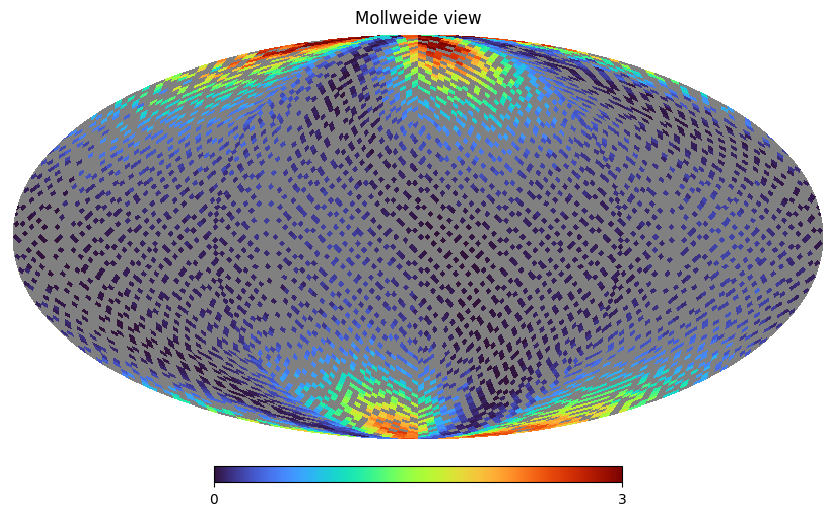

<Figure size 1000x600 with 0 Axes>

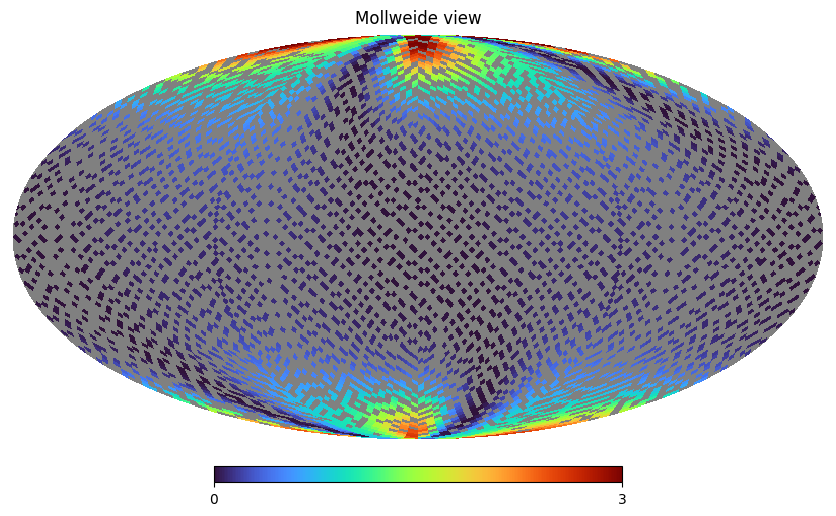

In [16]:
test_ch = 44 # 18 is weird, has a loss of about 7, but has all 0 almost everywhere # 34 has the same issue with loss=3, something horrible happened at these channels
rot = reduced[:, test_ch][sl][val][fitter.inds] #* norm[:, ch]
m_th = beam_maps_th[test_ch-13]
m_phi = beam_maps_ph[test_ch-13]


# low_th = healpy.ud_grade(m_th, 16)
# low_ph = healpy.ud_grade(m_phi, 16)
# m_th = low_th
# m_phi = low_ph


rx_true = RotatingAntenna(beam_th=m_th, beam_phi=m_phi)

test_alpha = best_alphas[test_ch-13] + 0
test_delta = best_deltas[test_ch-13] + 0
# test_alpha = best_alphas[test_ch] + 0
# test_delta = best_deltas[test_ch] + 0
# tx_true = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=alpha_angle[jnp.argmin(ress)])
# txe1 = jnp.sin(jnp.deg2rad(best_alphas[test_ch-13]))**2
# txe2 = jnp.cos(jnp.deg2rad(best_alphas[test_ch-13]))**2
txe1 = jnp.sin(jnp.deg2rad(test_alpha))**2
txe2 = jnp.cos(jnp.deg2rad(test_alpha))**2
coord = [0,0,-1]

tx_true = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)
# sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(70), K=1.0, C0=0.0)
sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(test_delta), K=1.0, C0=0.0)

test_data = rot * norm[:, test_ch]

sim_norm_rot = 1 / jnp.mean(sim_p_rot, axis=0)
sim_data = sim_p_rot * sim_norm_rot
scale_factor = jnp.sum(test_data * sim_data) / jnp.sum(sim_data**2)
# test_data = sim_data * scale_factor
# print(freqs[chs][test_ch], best_alphas[test_ch-13])
print(freqs[chs][test_ch], test_alpha, test_delta, best_losses[test_ch-13])
beam_proj(hit_pxs, rot*norm[:,test_ch])
beam_proj(hit_pxs, scale_factor * sim_data)
# beam_proj(hit_pxs, (scale_factor * sim_data) - (rot*norm[:,test_ch]), vmin=None, vmax=None)

121.09375 0.0 0.0 0.057676937


<Figure size 1000x600 with 0 Axes>

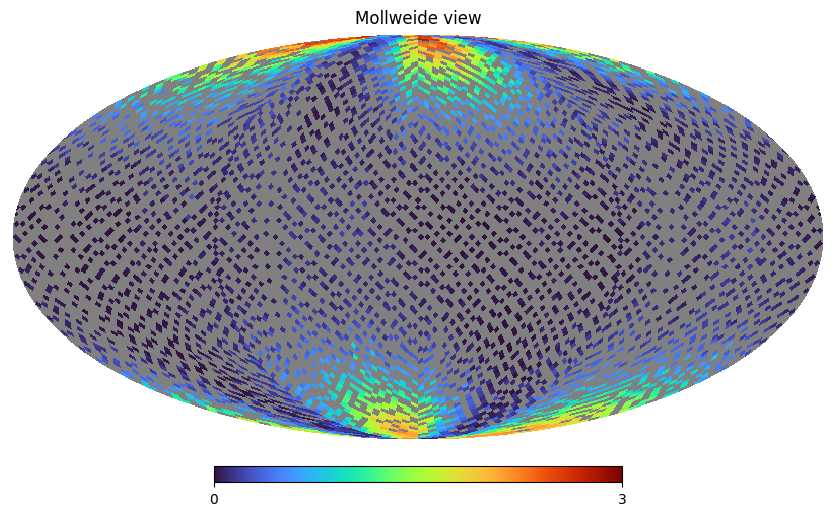

<Figure size 1000x600 with 0 Axes>

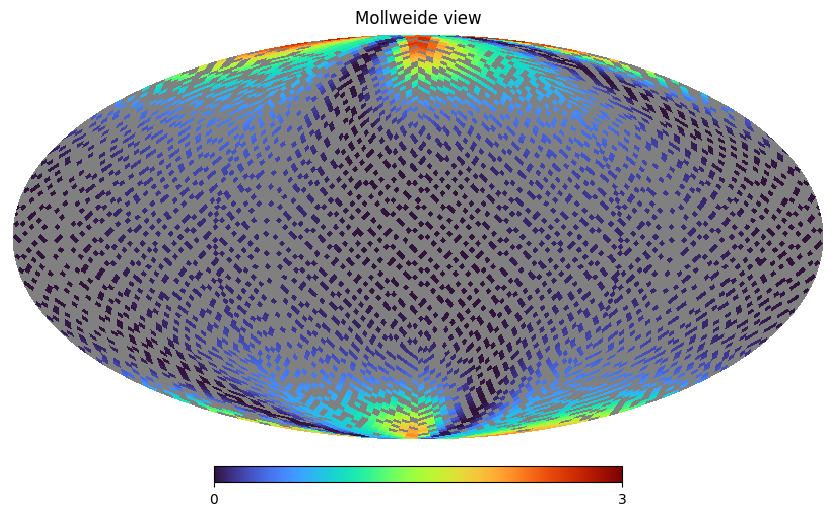

In [17]:
test_ch = 30 # 18 is weird, has a loss of about 7, but has all 0 almost everywhere # 34 has the same issue with loss=3, something horrible happened at these channels
m_th = beam_maps_th[test_ch]
m_phi = beam_maps_ph[test_ch]


# low_th = healpy.ud_grade(m_th, 16)
# low_ph = healpy.ud_grade(m_phi, 16)
# m_th = low_th
# m_phi = low_ph


rx_true = RotatingAntenna(beam_th=m_th, beam_phi=m_phi)

test_alpha = best_alphas[test_ch] + 0
test_delta = best_deltas[test_ch] + 0
# test_alpha = best_alphas[test_ch] + 0
# test_delta = best_deltas[test_ch] + 0
# tx_true = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=alpha_angle[jnp.argmin(ress)])
# txe1 = jnp.sin(jnp.deg2rad(best_alphas[test_ch-13]))**2
# txe2 = jnp.cos(jnp.deg2rad(best_alphas[test_ch-13]))**2
txe1 = jnp.sin(jnp.deg2rad(test_alpha))**2
txe2 = jnp.cos(jnp.deg2rad(test_alpha))**2
coord = [0,0,-1]

tx_true = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)
# sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(70), K=1.0, C0=0.0)
sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx_true, tx=tx_true, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(test_delta), K=1.0, C0=0.0)

test_data = rot[:, test_ch] * norm[:, test_ch]

sim_norm_rot = 1 / jnp.mean(sim_p_rot, axis=0)
sim_data = sim_p_rot * sim_norm_rot
scale_factor = jnp.sum(test_data * sim_data) / jnp.sum(sim_data**2)
# test_data = sim_data * scale_factor
# print(freqs[chs][test_ch], best_alphas[test_ch-13])
print(freqs[chs][test_ch], test_alpha, test_delta, best_losses[test_ch])
beam_proj(hit_pxs, test_data)
beam_proj(hit_pxs, scale_factor * sim_data)
# beam_proj(hit_pxs, (scale_factor * sim_data) - (rot*norm[:,test_ch]), vmin=None, vmax=None)

In [91]:
### original dont touch

def spectra_sims(m_th, m_ph, alphas, deltas, data, coord=[0, 0, -1], offset=13): # does sim at every frequency
    chans = data.shape[1] - offset
    spectra = jnp.empty(shape=(chans, data.shape[0]))
    for ch in range(offset, data.shape[1]):
        rx = RotatingAntenna(m_th[ch-offset], m_ph[ch-offset])
        txe1 = jnp.sin(jnp.deg2rad(alphas[ch-offset]))**2
        txe2 = jnp.cos(jnp.deg2rad(alphas[ch-offset]))**2
        tx = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)
        sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx, tx=tx, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(deltas[ch-offset]), K=1.0, C0=0.0)
        test_data = data[:, ch] * norm[:, ch]
        sim_norm_rot = 1 / jnp.mean(sim_p_rot, axis=0)
        sim_data = sim_p_rot * sim_norm_rot
        # scale_factor = jnp.sum(test_data * sim_data) / jnp.sum(sim_data**2)
        # spectra = spectra.at[i].set(scale_factor * sim_data)
        spectra = spectra.at[ch-offset].set(sim_data)
    return spectra

def fit_hera_pack(nterms, fc, fhw, weights, x, y): # best fits dpss modes
    A, _ = hf.dspec.dpss_operator(x=x, filter_centers=[fc], filter_half_widths=[fhw], nterms=[nterms])
    coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
    hera_model = A@coeff
    # print('A', A.shape, 'coeff', coeff.shape, 'model', hera_model.shape, 'data', y.shape)
    return hera_model, coeff

In [18]:
def spectra_sims(m_th, m_ph, alphas, deltas, data, coord=[0, 0, -1]): # does sim at every frequency
    chans = data.shape[1]  
    spectra = jnp.empty(shape=(chans, data.shape[0]))
    for ch in range(chans):
        rx = RotatingAntenna(m_th[ch], m_ph[ch])
        txe1 = jnp.sin(jnp.deg2rad(alphas[ch]))**2
        txe2 = jnp.cos(jnp.deg2rad(alphas[ch]))**2
        tx = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)
        sim_p_rot, hit_pxs = simulate_powers_vmap_phase(rx=rx, tx=tx, az=az_inds, el=el_inds, E1=txe1, E2=txe2, delta_rx=jnp.deg2rad(deltas[ch]), K=1.0, C0=0.0)
        test_data = data[:, ch] * norm[:, ch]
        sim_norm_rot = 1 / jnp.mean(sim_p_rot, axis=0)
        sim_data = sim_p_rot * sim_norm_rot
        # scale_factor = jnp.sum(test_data * sim_data) / jnp.sum(sim_data**2)
        # spectra = spectra.at[i].set(scale_factor * sim_data)
        spectra = spectra.at[ch].set(sim_data)
    return spectra

def fit_hera_pack(nterms, fc, fhw, weights, x, y): # best fits dpss modes
    A, _ = hf.dspec.dpss_operator(x=x, filter_centers=[fc], filter_half_widths=[fhw], nterms=[nterms])
    coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
    hera_model = A@coeff
    # print('A', A.shape, 'coeff', coeff.shape, 'model', hera_model.shape, 'data', y.shape)
    return hera_model, coeff

Some notes:
* for some reason, at low frequencies the above code breaks? it doesnt produce any power, i think its 0 everywhere, bug? stops at 12
* regardless, applying the dpss filter actually produces hit maps with a reasonable shape! we enforced a shape!
* i think we apply this to grad descent to force the shapes we want across frequency!
* next step should be to find the bug in the above code, then do a gradient descent with the above functions to find the beam maps!
* should see how this works on its own, then add spherical harmonics smoothing if its still not enough, not sure on the order yet


update:
* found the bug, it shfted everything by 13
* now its the high frequency that breaks

next update:
* fixed the bug, looks great now!
* average difference between hit maps is now in 1e-16 range!
* should go forward with grad descent next!

next update:
* i think if i want to use dpss with gradient descent, then i need to apply the solver to the maps themselves, makes sense, i was thinking about it wrong
* so i will have 2 dpss coefficients but a single A matrix for both since it only depends on frequency

In [19]:
# all_spec = spectra_sims(m_th=beam_maps_th, m_ph=beam_maps_ph, 
#                         alphas=best_alphas, deltas=best_deltas, 
#                         data=reduced[sl][val][fitter.inds])
all_spec = spectra_sims(m_th=beam_maps_th, m_ph=beam_maps_ph, 
                        alphas=best_alphas, deltas=best_deltas, 
                        data=rot)
# all_spec = spectra_sims_scan(m_th=beam_maps_th, m_ph=beam_maps_ph, 
                        # alphas=best_alphas, deltas=best_deltas, 
                        # data=reduced[sl][val][fitter.inds])
all_spec.shape

(51, 4409)

In [20]:
beam_maps_ph.shape, best_alphas.shape, best_deltas.shape, reduced[sl][val][fitter.inds].shape, norm[:,].shape

((51, 12288), (51,), (51,), (4409, 63), (1, 51))

In [21]:
nterms = 10
fc = 0.0
fwh = 1e-4
xs = freqs[chs][shift:]
# xs = freqs[::16][13:]
weights = np.ones_like(xs)
# rec_hits, dpss_terms = fit_hera_pack(nterms, fc, fwh, weights, xs, beam_maps_th[:-1])
rec_hits, dpss_terms = fit_hera_pack(nterms, fc, fwh, weights, xs, all_spec)
rec_hits.shape

(51, 4409)

(51,)


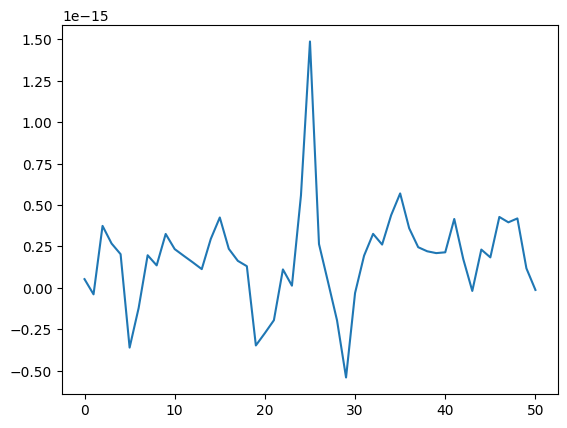

<Figure size 1000x600 with 0 Axes>

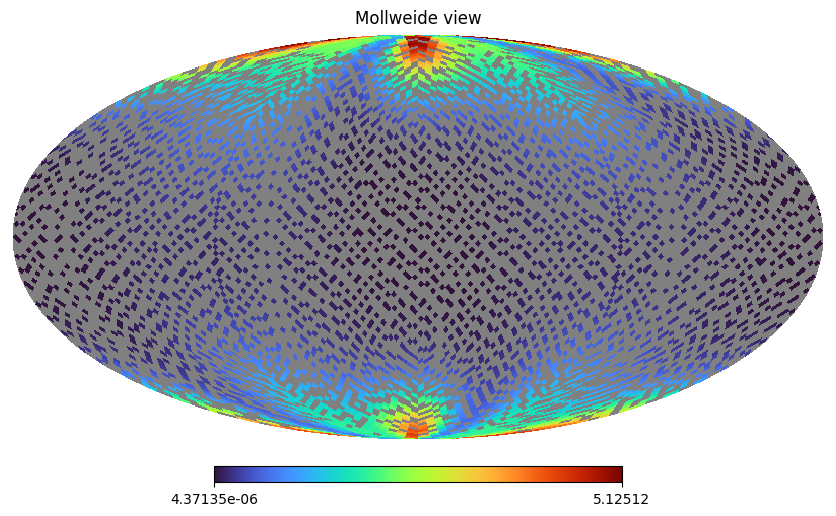

<Figure size 1000x600 with 0 Axes>

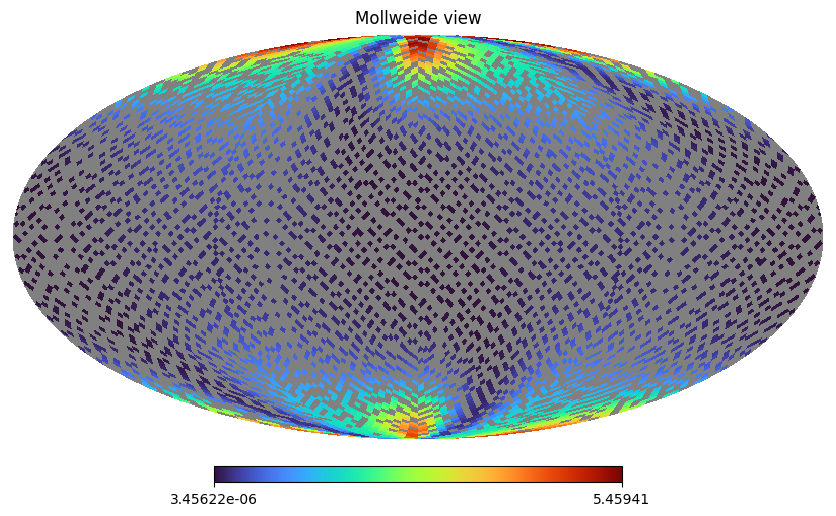

In [22]:
diff = jnp.empty((rec_hits.shape[0]))
print(diff.shape)
for i in range(rec_hits.shape[0]):
    # diff_ = jnp.mean(beam_maps_th[i] - rec_hits[i])
    diff_ = jnp.mean(all_spec[i] - rec_hits[i])
    diff = diff.at[i].set(diff_)

plt.figure()
plt.plot(diff)
plt.show()
# healpy.mollview(beam_maps_th[10])
beam_proj(hit_pxs, rec_hits[29], vmin=None, vmax=None) # dpss reconstruction
beam_proj(hit_pxs, all_spec[29], vmin=None, vmax=None) # power at sampled pixel

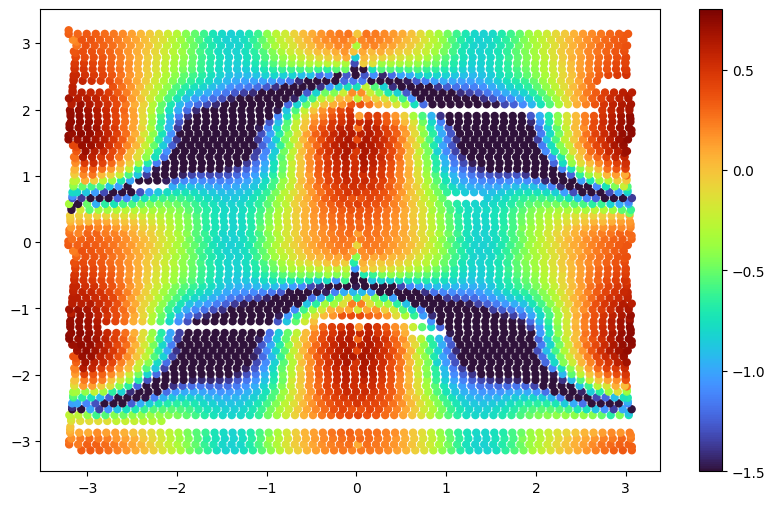

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(el_inds, az_inds, c=np.log10(all_spec[30]), s=25, cmap='turbo', vmin=-1.5, vmax=.8)
plt.colorbar()
plt.show()

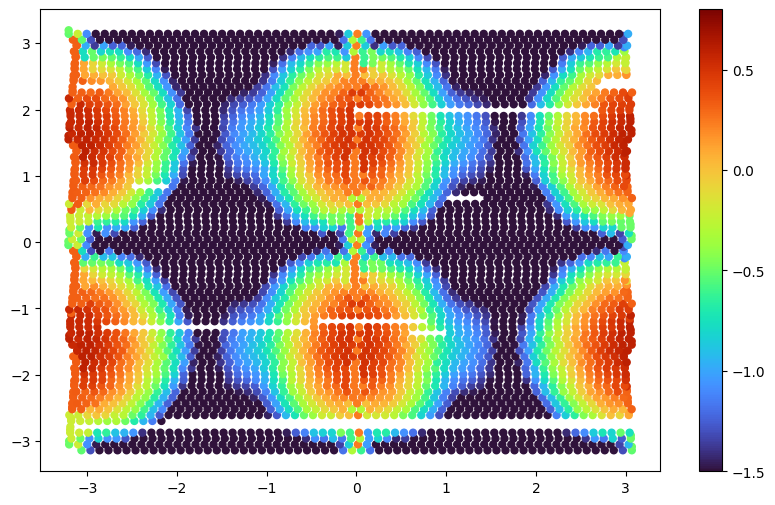

In [26]:

plt.figure(figsize=(10, 6))
plt.scatter(el_inds, az_inds, c=np.log10(beam_maps_th[test_ch][hit_pxs]), s=25, cmap='turbo', vmin=-1.5, vmax=.8)
plt.colorbar()
plt.show()

86
0


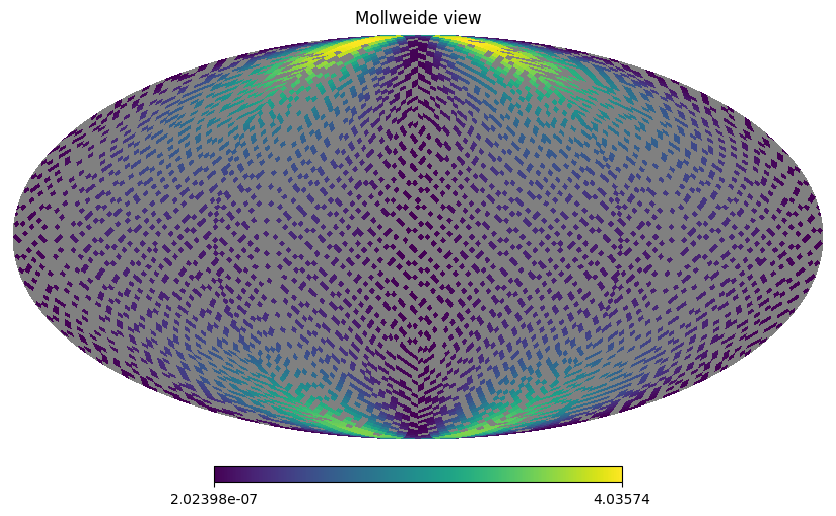

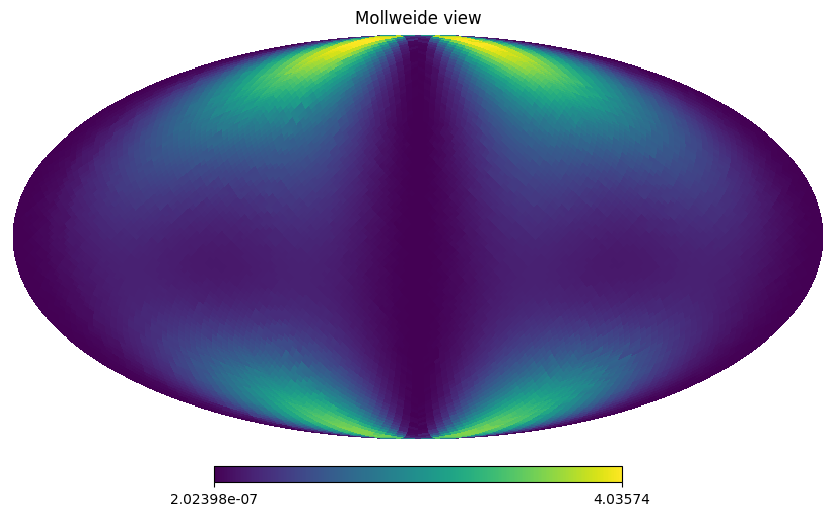

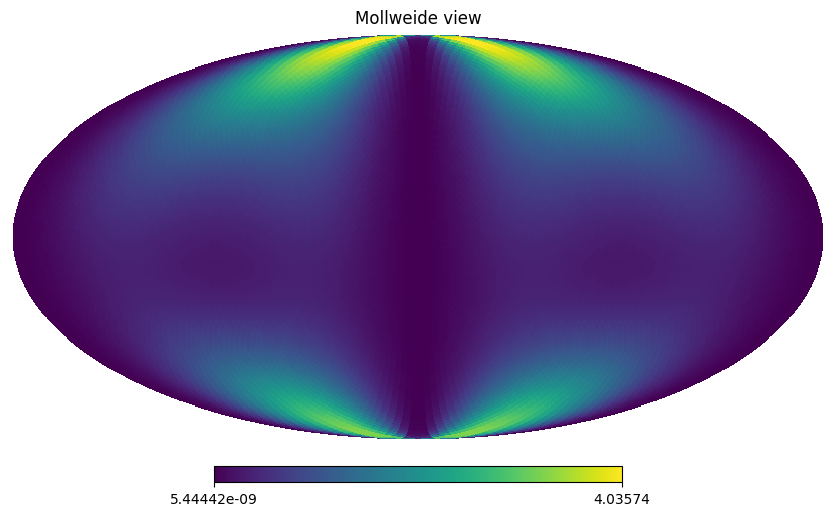

In [55]:
# def mean_fill(m, inds):
#     nside = healpy.get_nside(m)
#     npix = healpy.nside2npix(nside)
    
#     theta, phi = healpy.pix2ang(nside, inds)
#     nei = healpy.get_all_neighbours(nside, theta, phi)
    
#     m_fill = m.copy()
    
#     fill_mask = np.zeros(npix, dtype=bool)
#     fill_mask[inds] = True
    
#     nei_vals = m[nei]
    
#     bad = (nei < 0) | fill_mask[nei] | (nei_vals == healpy.UNSEEN)
#     nei_vals = np.where(bad, np.nan, nei_vals)
    
#     m_fill[inds] = np.nanmean(nei_vals, axis=0)
#     check = np.where(m_fill == healpy.UNSEEN)
#     lim = check[0].size
#     print(lim)
#     if lim != 0:
#         m_fill = mean_fill(m_fill, check[0])
#     return m_fill

# import numpy as np
# import healpy

def mean_fill(m, inds):
    nside = healpy.get_nside(m)
    npix = healpy.nside2npix(nside)

    # inds must be a 1D index array, not a tuple from np.where
    inds = np.asarray(inds)
    if inds.ndim > 1:
        inds = inds[0]

    theta, phi = healpy.pix2ang(nside, inds)
    nei = healpy.get_all_neighbours(nside, theta, phi)  # shape (8, N)

    m_fill = m.copy()

    fill_mask = np.zeros(npix, dtype=bool)
    fill_mask[inds] = True

    nei_vals = m_fill[nei]  # use m_fill so later passes can use filled values

    bad = (nei < 0) | fill_mask[nei] | (nei_vals == healpy.UNSEEN)
    nei_vals = np.where(bad, np.nan, nei_vals)

    means = np.nanmean(nei_vals, axis=0)

    # if ALL neighbours were invalid, keep UNSEEN so it can be retried later
    no_valid = np.all(np.isnan(nei_vals), axis=0)
    means[no_valid] = healpy.UNSEEN

    m_fill[inds] = means

    check = np.where(m_fill == healpy.UNSEEN)[0]
    print(check.size)
    if check.size != 0:
        m_fill = mean_fill(m_fill, check)  # NOTE: check is already [0] now

    return m_fill


test_fill = np.full(shape=beam_maps_ph[test_ch].shape[0], fill_value=healpy.UNSEEN)
test_fill[hit_pxs] = beam_maps_ph[test_ch][hit_pxs]
# miss_pxs = np.linspace(0, beam_maps_ph[test_ch].shape[0], beam_maps_ph[test_ch].shape[0])
# miss_pxs = np.where(miss_pxs != hit_pxs)
# miss_pxs = np.setdiff1d(np.arange(beam_maps_ph.shape[0]), hit_pxs)
miss_pxs = np.where(test_fill == healpy.UNSEEN)

maybe = mean_fill(test_fill, miss_pxs)

healpy.mollview(test_fill)
healpy.mollview(maybe)
healpy.mollview(beam_maps_ph[test_ch])

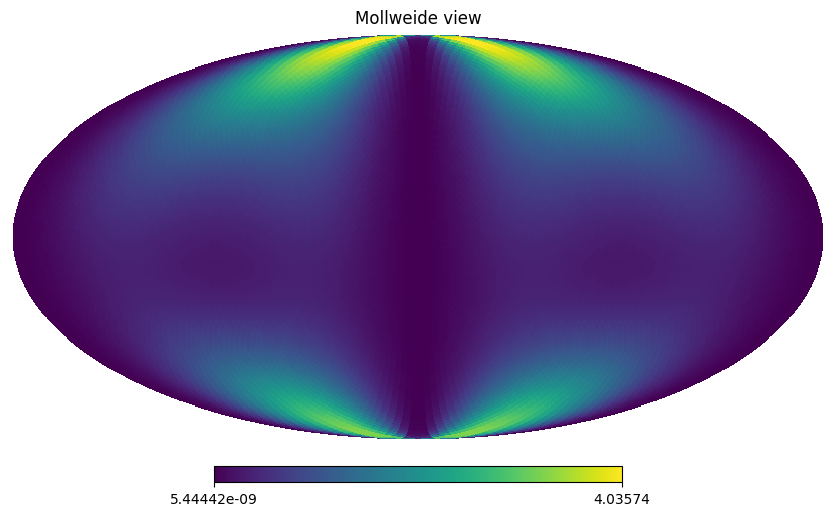

In [56]:
import numpy as np
import healpy as hp

import jax
import jax.numpy as jnp
from jax import lax


def precompute_neighbours(nside: int) -> np.ndarray:
    """Return neighbour table of shape (8, npix) with -1 for missing neighbours."""
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, pix)
    nei = hp.get_all_neighbours(nside, theta, phi)  # (8, npix), ints, may contain -1
    return nei


@jax.jit
def mean_fill_jax(m: jnp.ndarray,
                  nei: jnp.ndarray,
                  unseen_value: float = hp.UNSEEN) -> jnp.ndarray:
    """
    JAX-friendly mean-fill of HEALPix map values marked as `unseen_value`.

    Args:
      m: (npix,) float array
      nei: (8, npix) int array, neighbour indices with -1 where invalid
      unseen_value: sentinel value used by healpy for unseen pixels

    Returns:
      Filled map (npix,)
    """
    npix = m.shape[0]

    # For safe gathers, clamp -1 -> 0 (we'll mask these out anyway)
    nei_safe = jnp.clip(nei, 0, npix - 1)

    def body(state):
        m_cur, _ = state

        unseen_mask = (m_cur == unseen_value)

        # Gather neighbour values: shape (8, npix)
        vals = m_cur[nei_safe]

        # Mask invalid neighbours: out-of-range OR neighbour is UNSEEN
        invalid = (nei < 0) | (vals == unseen_value)
        vals = jnp.where(invalid, jnp.nan, vals)

        # Compute neighbour means; if all neighbours invalid -> NaN
        means = jnp.nanmean(vals, axis=0)

        has_valid = jnp.any(~jnp.isnan(vals), axis=0)

        # Only fill pixels that are currently UNSEEN and have at least one valid neighbour
        updates = unseen_mask & has_valid
        fill_values = jnp.where(has_valid, means, unseen_value)

        m_next = jnp.where(updates, fill_values, m_cur)

        # progress flag (whether we filled anything this iteration)
        did_update = jnp.any(updates)
        return (m_next, did_update)

    def cond(state):
        m_cur, did_update = state
        still_unseen = jnp.any(m_cur == unseen_value)
        # keep looping only if there are UNSEEN pixels AND we made progress last iter
        return still_unseen & did_update

    # First iteration should be allowed to run, so seed did_update=True
    m_out, _ = lax.while_loop(cond, body, (m, jnp.array(True)))
    return m_out

# nside = hp.get_nside(m_np)                 # m_np is your numpy healpy map
nei_np = precompute_neighbours(DEFAULT_NSIDE)      # (8, npix) numpy

m_np = beam_maps_ph[test_ch]
m_j = jnp.asarray(m_np)
nei_j = jnp.asarray(nei_np)

m_filled = mean_fill_jax(m_j, nei_j)       # JAX array
# m_filled_np = np.array(m_filled)           # back to numpy if needed

healpy.mollview(m_filled)

In [23]:
### original, dont touch
def spectra_sims_scan(m_th, m_ph, alphas, deltas, data, coord=jnp.array([0., 0., -1.]), offset=13):
    # m_th, m_ph expected shape: (chans, Npix) where chans = data.shape[1] - offset
    chans = data.shape[1] - offset

    data_use = data[:, offset:]         # shape: (Nmeas, chans)
    norm_use = norm[:, offset:]         # <-- if norm is global, consider passing it in

    alph = alphas[:chans]
    delt = deltas[:chans]
    txe1_all = jnp.sin(jnp.deg2rad(alph))**2
    txe2_all = jnp.cos(jnp.deg2rad(alph))**2

    def body(carry, inputs):
        mth_ch, mph_ch, txe1, txe2, delta, data_ch, norm_ch = inputs

        rx = RotatingAntenna(mth_ch, mph_ch)
        tx = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)

        sim_p_rot, hit_pxs = simulate_powers_vmap_phase(
            rx=rx, tx=tx,
            az=az_inds, el=el_inds,
            E1=txe1, E2=txe2,
            delta_rx=jnp.deg2rad(delta),
            K=1.0, C0=0.0
        )

        # If you don't use test_data downstream, remove it:
        # test_data = data_ch * norm_ch

        sim_norm_rot = 1.0 / jnp.mean(sim_p_rot, axis=0)
        sim_data = sim_p_rot * sim_norm_rot

        return carry, sim_data  # scan stacks sim_data over chans

    inputs = (m_th[:chans], m_ph[:chans], txe1_all, txe2_all, delt, data_use.T, norm_use.T)
    _, spectra = jax.lax.scan(body, None, inputs)  # spectra shape: (chans, ...)
    return spectra


In [24]:
def spectra_sims_scan(m_th, m_ph, alphas, deltas, data, coord=jnp.array([0., 0., -1.])):
    # m_th, m_ph expected shape: (chans, Npix) where chans = data.shape[1] - offset
    chans = data.shape[1]

    data_use = data         # shape: (Nmeas, chans)
    norm_use = norm         # <-- if norm is global, consider passing it in

    # alph = alphas[:chans]
    # delt = deltas[:chans]
    alph = alphas
    delt = deltas
    txe1_all = jnp.sin(jnp.deg2rad(alph))**2
    txe2_all = jnp.cos(jnp.deg2rad(alph))**2

    def body(carry, inputs):
        mth_ch, mph_ch, txe1, txe2, delta, data_ch, norm_ch = inputs

        rx = RotatingAntenna(mth_ch, mph_ch)
        tx = TransmitterAntenna(E1=txe1, E2=txe2, heading_top=coord, alpha=-32)

        sim_p_rot, hit_pxs = simulate_powers_vmap_phase(
            rx=rx, tx=tx,
            az=az_inds, el=el_inds,
            E1=txe1, E2=txe2,
            delta_rx=jnp.deg2rad(delta),
            K=1.0, C0=0.0
        )

        # If you don't use test_data downstream, remove it:
        # test_data = data_ch * norm_ch

        sim_norm_rot = 1.0 / jnp.mean(sim_p_rot, axis=0)
        sim_data = sim_p_rot * sim_norm_rot

        return carry, sim_data  # scan stacks sim_data over chans

    # inputs = (m_th[:chans], m_ph[:chans], txe1_all, txe2_all, delt, data_use.T, norm_use.T)
    inputs = (m_th, m_ph, txe1_all, txe2_all, delt, data_use.T, norm_use.T)
    _, spectra = jax.lax.scan(body, None, inputs)  # spectra shape: (chans, ...)
    return spectra


In [60]:
from functools import partial
import healpy as hp
import jax
import jax.numpy as jnp
from jax import lax

@partial(jax.jit, static_argnames=("max_iters",))
def mean_fill_jax_freqpix(m: jnp.ndarray,
                                nei: jnp.ndarray,
                                max_iters: int,
                                unseen_value: float = hp.UNSEEN) -> jnp.ndarray:
    """
    m:   (F, P)
    nei: (8, P) with -1 for invalid
    max_iters: STATIC iteration cap (required for reverse-mode grad)
    """
    F, P = m.shape
    nei_safe = jnp.clip(nei, 0, P - 1)  # safe gather

    def step(_, m_cur):
        # gather neighbor values: (F, 8, P)
        vals = m_cur[:, nei_safe]

        # valid neighbor mask: (F, 8, P)
        valid = (nei >= 0)[None, :, :] & (vals != unseen_value)

        # mean = sum/count over the 8 neighbor axis
        vals0 = jnp.where(valid, vals, 0.0)
        s = jnp.sum(vals0, axis=1)                          # (F, P)
        c = jnp.sum(valid.astype(m_cur.dtype), axis=1)      # (F, P)

        mean = s / jnp.where(c > 0, c, 1.0)

        # only fill currently-unseen pixels that have at least one valid neighbor
        updates = (m_cur == unseen_value) & (c > 0)
        m_next = jnp.where(updates, mean, m_cur)
        return m_next

    return lax.fori_loop(0, max_iters, step, m)


In [80]:
### best so far, only does dpss
# lr = 1e-3
# nterms = 5
# fc = 0.0
# fwh = 1e-2
# xs = freqs[::16][13:-1]
# # xs = freqs[::16][13:]
# weights = np.ones_like(xs)
# A_mat, _ = hf.dspec.dpss_operator(x=xs, filter_centers=[fc], filter_half_widths=[fwh], nterms=[nterms])
# A_mat = jnp.asarray(A_mat)
# y_dat = jnp.asarray(reduced[sl][val][fitter.inds]) ### forgot to normalize!!!!!!
# # xs = jnp.asarray(xs)


# th_init = jnp.ones(shape=(nterms, m_th.shape[0]), dtype=dtype_r) * 1e15
# ph_init = jnp.ones(shape=(nterms, m_ph.shape[0]), dtype=dtype_r) * 1e15

# # model is just spectra_sims
# def loss_fnc(params_raw):
#     dpss_th = params_raw[0]
#     dpss_ph = params_raw[1]
#     rec_th = jax.nn.softplus(A_mat@dpss_th)
#     rec_ph = jax.nn.softplus(A_mat@dpss_ph)
#     # y_dat = reduced[sl][val][fitter.inds]
#     y_mod = spectra_sims_scan(m_th=rec_th, m_ph=rec_ph, alphas=best_alphas, deltas=best_deltas, data=y_dat)
#     loss = jnp.mean((y_dat[:, 13:].T - y_mod)**2)
#     return loss
###
# nei_np = precompute_neighbours(DEFAULT_NSIDE)      # (8, npix) numpy

# m_np = beam_maps_ph[test_ch]
# nei_j = jnp.asarray(nei_np)

# m_filled = mean_fill_jax(m_j, nei_j)       # JAX array
# m_filled_np = np.array(m_filled)           # back to numpy if needed

### had lr=1e-3, nterms=15, fc=0, fwh=1e-2 for most of it, consider these as defaults, they made the speckled maps
lr = 1e-4
nterms = 15
fc = 0.0
fwh = 1e-2
# xs = freqs[::16][13:]
xs = freqs[chs][shift:]
# xs = freqs[::16][13:]
weights = np.ones_like(xs)
A_mat, _ = hf.dspec.dpss_operator(x=xs, filter_centers=[fc], filter_half_widths=[fwh], nterms=[nterms])
A_mat = jnp.asarray(A_mat)
# y_dat = jnp.asarray(reduced[sl][val][fitter.inds])
# y_dat = (rot * norm).T
y_dat = jnp.asarray(spectra_sims_scan(m_th=beam_maps_th, 
                                      m_ph=beam_maps_ph, 
                                      alphas=best_alphas, 
                                      deltas=best_deltas, 
                                      data=jnp.asarray(rot)))
print(xs.shape, A_mat.shape, y_dat.shape)
# _, th_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=np.ones_like(xs), y=beam_maps_th[1:-1, :])
# _, ph_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=np.ones_like(xs), y=beam_maps_ph[1:-1, :])
_, th_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=np.ones_like(xs), y=beam_maps_th)
_, ph_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=np.ones_like(xs), y=beam_maps_ph)
print(y_dat.shape)
def loss_fnc(params_raw):
    dpss_th = params_raw[0]
    dpss_ph = params_raw[1]
    rec_th = jax.nn.softplus(A_mat@dpss_th)
    rec_ph = jax.nn.softplus(A_mat@dpss_ph)

    # rec_th = mean_fill_jax_freqpix(rec_th, nei_j, max_iters=10)
    # rec_ph = mean_fill_jax_freqpix(rec_ph, nei_j, max_iters=10)
    # y_dat = reduced[sl][val][fitter.inds]
    y_mod = spectra_sims_scan(m_th=rec_th, m_ph=rec_ph, alphas=best_alphas, deltas=best_deltas, data=jnp.asarray(rot))
    loss = jnp.mean((y_dat - y_mod)**2)
    return loss
# th_init = jnp.ones(shape=(nterms, m_th.shape[0]), dtype=dtype_r) * 1e3
# ph_init = jnp.ones(shape=(nterms, m_ph.shape[0]), dtype=dtype_r) * 1e3





from functools import partial
import jax
import jax.numpy as jnp
import optax
import numpy as np

# optimizer = optax.adam(learning_rate=lr)
optimizer = optax.adamw(learning_rate=lr, weight_decay=1e-6)

@jax.jit
def train_step(params_raw, opt_state):
    loss_val, grads = jax.value_and_grad(loss_fnc)(params_raw)
    updates, opt_state = optimizer.update(grads, opt_state, params_raw)
    params_raw = optax.apply_updates(params_raw, updates)
    return params_raw, opt_state, loss_val

@partial(jax.jit, static_argnames=("chunk_steps",))
def run_chunk(params_raw, opt_state, chunk_steps: int):
    def body(carry, _):
        params_raw, opt_state = carry
        params_raw, opt_state, loss_val = train_step(params_raw, opt_state)
        return (params_raw, opt_state), loss_val

    (params_raw, opt_state), losses = jax.lax.scan(
        body, (params_raw, opt_state), xs=None, length=chunk_steps
    )
    return params_raw, opt_state, losses


num_steps   = 1000
chunk_steps = 200                      # print every 200 steps
n_chunks    = (num_steps + chunk_steps - 1) // chunk_steps

params_raw = (th_init, ph_init)
opt_state  = optimizer.init(params_raw)

loss_list = []
step_ctr = 0

for k in range(n_chunks):
    params_raw, opt_state, losses = run_chunk(params_raw, opt_state, chunk_steps=chunk_steps)

    # Sync HERE so you don't "hang" later:
    losses_np = np.asarray(jax.device_get(losses))
    loss_list.append(losses_np)

    step_ctr += chunk_steps
    print(f"{min(step_ctr, num_steps):05d}  loss={losses_np[-1]:.3e}")

loss_arr = np.concatenate(loss_list)[:num_steps]



print('solver done')
final_th_dpss = params_raw[0]
final_ph_dpss = params_raw[1]
final_th = jax.nn.softplus(A_mat@final_th_dpss)
final_ph = jax.nn.softplus(A_mat@final_ph_dpss)

# final_th = final_th.block_until_ready()
# print("final_th ready")


(51,) (51, 15) (51, 4409)
(51, 4409)
00200  loss=6.503e-02
00400  loss=6.307e-02
00600  loss=6.124e-02
00800  loss=5.952e-02
01000  loss=5.790e-02
solver done


In [92]:
### doing both dpss and spherical harmonics
from scipy.special import sph_harm_y
from scipy.linalg import lstsq

def build_real_design_matrix(nside, lmax, ipix, nest=False):
    """
    A has shape (n_obs, (lmax+1)^2) and maps real parameters x -> real map values at ipix.
    Parameter layout:
      for l=0..lmax:
        x contains a_{l0}  (real)
        for m=1..l:
          x contains Re(a_{lm}), Im(a_{lm})
    """
    theta, phi = hp.pix2ang(nside, ipix, nest=nest)  # theta=colatitude, phi=longitude

    npar = (lmax + 1) ** 2
    A = np.empty((ipix.size, npar), dtype=np.float64)

    k = 0
    for l in range(lmax + 1):
        # m=0: Y_{l0} is real (with SciPy convention)
        Y = sph_harm_y(l, 0, theta, phi)
        A[:, k] = Y.real
        k += 1

        # m>0: contribution is 2*Re( a_lm * Y_lm )
        for m in range(1, l + 1):
            Y = sph_harm_y(l, m, theta, phi)
            A[:, k]   =  2.0 * Y.real   # coefficient for Re(a_lm)
            A[:, k+1] = -2.0 * Y.imag   # coefficient for Im(a_lm)
            k += 2

    return A

def x_to_alm(x, lmax):
    """Convert the real-parameter vector x into a healpy alm array (m>=0 storage)."""
    alm = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    k = 0
    for l in range(lmax + 1):
        alm[hp.Alm.getidx(lmax, l, 0)] = x[k]  # real
        k += 1
        for m in range(1, l + 1):
            ar, ai = x[k], x[k+1]
            alm[hp.Alm.getidx(lmax, l, m)] = ar + 1j * ai
            k += 2
    return alm



def fit_alms_many_maps(maps, nside, lmax, user_weights=None, nest=False):
    """
    maps: array (n_maps, npix) or (npix,) for single map.
    user_weights: optional array (npix,) with 0/1 or general nonnegative weights.
                 UNSEEN pixels are automatically given weight 0 via masking below.
    Returns: alm array of shape (n_maps, hp.Alm.getsize(lmax))
    """
    maps = np.asarray(maps)
    if maps.ndim == 1:
        maps = maps[None, :]
    n_maps, npix = maps.shape

    # valid pixels per map: not UNSEEN and finite
    valid = (maps != hp.UNSEEN) & np.isfinite(maps)

    # common valid set so we can reuse one A
    common = np.all(valid, axis=0)
    ipix = np.where(common)[0]

    # Build design matrix once on these pixels
    A = build_real_design_matrix(nside, lmax, ipix, nest=nest)   # (n_obs, n_par)

    # Stack all map data as multiple RHS: (n_obs, n_maps)
    D = maps[:, ipix].T.astype(np.float64)

    # Optional extra weights (in addition to dropping UNSEEN)
    if user_weights is not None:
        w = np.asarray(user_weights)[ipix].astype(np.float64)
        w = np.clip(w, 0.0, np.inf)
        sw = np.sqrt(w)
        A = A * sw[:, None]
        D = D * sw[:, None]

    # Solve once for all maps: returns X (n_par, n_maps)
    X, *_ = lstsq(A, D)   # SciPy supports b with shape (M, K) :contentReference[oaicite:2]{index=2}

    # Convert each column of X into healpy alm
    nalm = hp.Alm.getsize(lmax)  # :contentReference[oaicite:3]{index=3}
    alms = np.empty((n_maps, nalm), dtype=np.complex128)
    for i in range(n_maps):
        alms[i] = x_to_alm(X[:, i], lmax)

    return alms


def alm_to_x(alm, lmax):
    """alm: shape (nalm,), healpy m>=0 storage -> x: shape ((lmax+1)^2,) real params."""
    x = np.zeros((lmax + 1) ** 2, dtype=np.float64)
    k = 0
    for l in range(lmax + 1):
        # m=0
        idx0 = hp.Alm.getidx(lmax, l, 0)
        x[k] = np.real(alm[idx0])
        k += 1
        # m>0
        for m in range(1, l + 1):
            idx = hp.Alm.getidx(lmax, l, m)
            x[k]   = np.real(alm[idx])
            x[k+1] = np.imag(alm[idx])
            k += 2
    return x

def alms_to_xs(alms, lmax):
    """alms: (n_maps, nalm) -> xs: (n_maps, (lmax+1)^2)"""
    return np.stack([alm_to_x(a, lmax) for a in alms], axis=0)


### had lr=1e-3, nterms=15, fc=0, fwh=1e-2 for most of it, consider these as defaults, they made the speckled maps
lr = 1e-4
lmax = 16
nterms = 15
fc = 0.0
fwh = 1e-2
# xs = freqs[::16][13:]
xs = freqs[chs][shift:]
# xs = freqs[::16][13:]
weights = np.ones_like(xs)
A_mat, _ = hf.dspec.dpss_operator(x=xs, filter_centers=[fc], filter_half_widths=[fwh], nterms=[nterms])
A_mat = jnp.asarray(A_mat)
# outside jit:
A_pix_np = build_real_design_matrix(DEFAULT_NSIDE, lmax, hit_pxs, nest=False)  # (n_hit, npar)
A_pix = jnp.asarray(A_pix_np)  # JAX constant
npar = A_pix.shape[1]
npix = hp.nside2npix(DEFAULT_NSIDE)


# y_dat = jnp.asarray(reduced[sl][val][fitter.inds])
# y_dat = (rot * norm).T
sim_dat = jnp.asarray(spectra_sims_scan(m_th=beam_maps_th, 
                                      m_ph=beam_maps_ph, 
                                      alphas=best_alphas, 
                                      deltas=best_deltas, 
                                      data=jnp.asarray(rot)))
proj_data = jnp.full_like(beam_maps_th, healpy.UNSEEN)
proj_data = proj_data.at[:, hit_pxs].set(sim_dat)
# y_sph = fit_alms_many_maps(maps=proj_data, nside=DEFAULT_NSIDE, lmax=lmax)
# _, y_dat = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=weights, y=y_sph)
y_dat=sim_data

# y_dat = jnp.asarray(spectra_sims_scan(m_th=beam_maps_th, 
#                                       m_ph=beam_maps_ph, 
#                                       alphas=best_alphas, 
#                                       deltas=best_deltas, 
#                                       data=jnp.asarray(rot)))
print(xs.shape, A_mat.shape, y_dat.shape)
# _, th_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=np.ones_like(xs), y=beam_maps_th[1:-1, :])
# _, ph_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=np.ones_like(xs), y=beam_maps_ph[1:-1, :])

# th_sph = fit_alms_many_maps(maps=beam_maps_th, nside=DEFAULT_NSIDE, lmax=lmax)
# ph_sph = fit_alms_many_maps(maps=beam_maps_ph, nside=DEFAULT_NSIDE, lmax=lmax)
# _, th_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=weights, y=th_sph)
# _, ph_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=weights, y=ph_sph)
th_sph = fit_alms_many_maps(maps=beam_maps_th, nside=DEFAULT_NSIDE, lmax=lmax)
ph_sph = fit_alms_many_maps(maps=beam_maps_ph, nside=DEFAULT_NSIDE, lmax=lmax)

th_x = alms_to_xs(th_sph, lmax)   # (n_maps, 289)
ph_x = alms_to_xs(ph_sph, lmax)

_, th_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=weights, y=th_x)
_, ph_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=xs, weights=weights, y=ph_x)


print(y_dat.shape)
# def loss_fnc(params_raw):
#     dpss_th = params_raw[0]
#     dpss_ph = params_raw[1]
#     # rec_th = jax.nn.softplus(A_mat@dpss_th)
#     # rec_ph = jax.nn.softplus(A_mat@dpss_ph)
#     rec_th = (A_mat@dpss_th)
#     rec_ph = (A_mat@dpss_ph)
    
#     rec_th = jnp.stack([hp.alm2map(rec_th[i], DEFAULT_NSIDE, lmax=lmax).real for i in range(rec_th.shape[0])])
#     rec_ph = jnp.stack([hp.alm2map(rec_ph[i], DEFAULT_NSIDE, lmax=lmax).real for i in range(rec_th.shape[0])])

#     y_mod = spectra_sims_scan(m_th=rec_th, m_ph=rec_ph, alphas=best_alphas, deltas=best_deltas, data=jnp.asarray(rot))
#     loss = jnp.mean((y_dat - y_mod)**2)
#     return loss
# th_init = jnp.ones(shape=(nterms, m_th.shape[0]), dtype=dtype_r) * 1e3
# ph_init = jnp.ones(shape=(nterms, m_ph.shape[0]), dtype=dtype_r) * 1e3

def loss_fnc(params_raw):
    dpss_th_x, dpss_ph_x = params_raw   # shapes (nterms, npar)

    # reconstruct coefficient vectors vs frequency: (n_freq, npar)
    x_th = A_mat @ dpss_th_x
    x_ph = A_mat @ dpss_ph_x

    # synthesize maps on hit pixels only: (n_freq, n_hit)
    m_th_hit = x_th @ A_pix.T
    m_ph_hit = x_ph @ A_pix.T

    # if your downstream needs full maps, scatter into full sky:
    m_th = jnp.full((m_th_hit.shape[0], npix), hp.UNSEEN).at[:, hit_pxs].set(m_th_hit)
    m_ph = jnp.full((m_ph_hit.shape[0], npix), hp.UNSEEN).at[:, hit_pxs].set(m_ph_hit)

    y_mod = spectra_sims_scan(
        m_th=m_th, m_ph=m_ph,
        alphas=best_alphas, deltas=best_deltas,
        data=jnp.asarray(rot)
    )
    return jnp.mean((y_dat - y_mod) ** 2)





from functools import partial
import jax
import jax.numpy as jnp
import optax
import numpy as np

# optimizer = optax.adam(learning_rate=lr)
optimizer = optax.adamw(learning_rate=lr, weight_decay=1e-6)

@jax.jit
def train_step(params_raw, opt_state):
    loss_val, grads = jax.value_and_grad(loss_fnc)(params_raw)
    updates, opt_state = optimizer.update(grads, opt_state, params_raw)
    params_raw = optax.apply_updates(params_raw, updates)
    return params_raw, opt_state, loss_val

@partial(jax.jit, static_argnames=("chunk_steps",))
def run_chunk(params_raw, opt_state, chunk_steps: int):
    def body(carry, _):
        params_raw, opt_state = carry
        params_raw, opt_state, loss_val = train_step(params_raw, opt_state)
        return (params_raw, opt_state), loss_val

    (params_raw, opt_state), losses = jax.lax.scan(
        body, (params_raw, opt_state), xs=None, length=chunk_steps
    )
    return params_raw, opt_state, losses


num_steps   = 1000
chunk_steps = 200                      # print every 200 steps
n_chunks    = (num_steps + chunk_steps - 1) // chunk_steps

params_raw = (th_init, ph_init)
opt_state  = optimizer.init(params_raw)

loss_list = []
step_ctr = 0

for k in range(n_chunks):
    params_raw, opt_state, losses = run_chunk(params_raw, opt_state, chunk_steps=chunk_steps)

    # Sync HERE so you don't "hang" later:
    losses_np = np.asarray(jax.device_get(losses))
    loss_list.append(losses_np)

    step_ctr += chunk_steps
    print(f"{min(step_ctr, num_steps):05d}  loss={losses_np[-1]:.3e}")

loss_arr = np.concatenate(loss_list)[:num_steps]



print('solver done')
final_th_dpss = params_raw[0]
final_ph_dpss = params_raw[1]
# final_th = jax.nn.softplus(A_mat@final_th_dpss)
# final_ph = jax.nn.softplus(A_mat@final_ph_dpss)
final_th = (A_mat@final_th_dpss)
final_ph = (A_mat@final_ph_dpss)

final_th = jnp.stack([hp.alm2map(final_th[i], DEFAULT_NSIDE, lmax=lmax).real for i in range(final_th.shape[0])])
final_th = jnp.stack([hp.alm2map(final_th[i], DEFAULT_NSIDE, lmax=lmax).real for i in range(final_th.shape[0])])
# final_th = final_th.block_until_ready()
# print("final_th ready")


(51,) (51, 15) (4409,)
(4409,)
00200  loss=nan


KeyboardInterrupt: 

In [255]:
y_dat = jnp.asarray(spectra_sims_scan(m_th=beam_maps_th[1:-1], 
                                      m_ph=beam_maps_ph[1:-1], 
                                      alphas=best_alphas[1:], 
                                      deltas=best_deltas[1:], 
                                      data=jnp.asarray(reduced[sl][val][fitter.inds])))
beam_maps_ph[1:-1].shape, xs.shape, y_dat.shape, best_alphas[1:].shape, reduced[:, 13:][sl][val][fitter.inds].shape

ValueError: scan got values with different leading axis sizes: 49, 49, 50, 50, 50, 51, 51.

In [27]:
y_dat = jnp.asarray(spectra_sims_scan(m_th=beam_maps_th, 
                                      m_ph=beam_maps_ph, 
                                      alphas=best_alphas, 
                                      deltas=best_deltas, 
                                      data=jnp.asarray(rot)))
beam_maps_ph.shape, xs.shape, y_dat.shape, best_alphas.shape, rot.shape

((51, 12288), (51,), (51, 4409), (51,), (4409, 51))

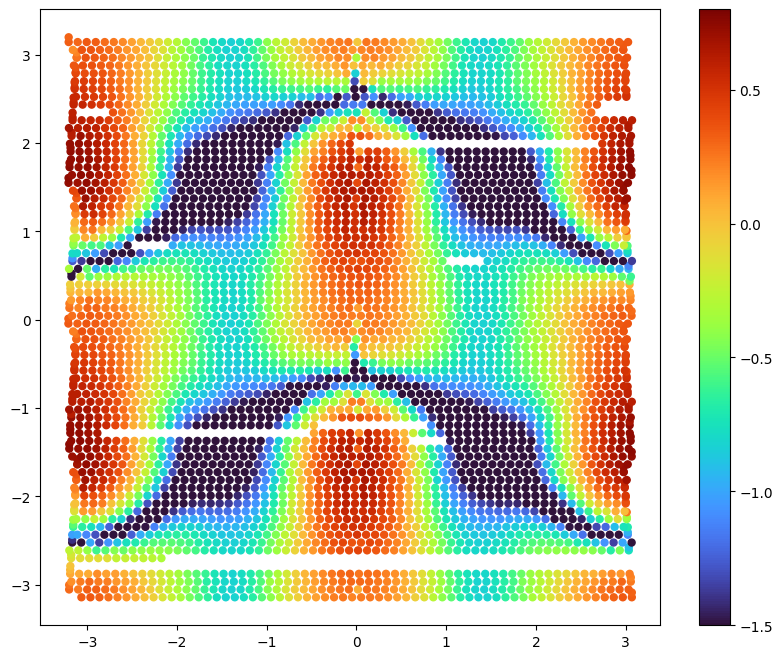

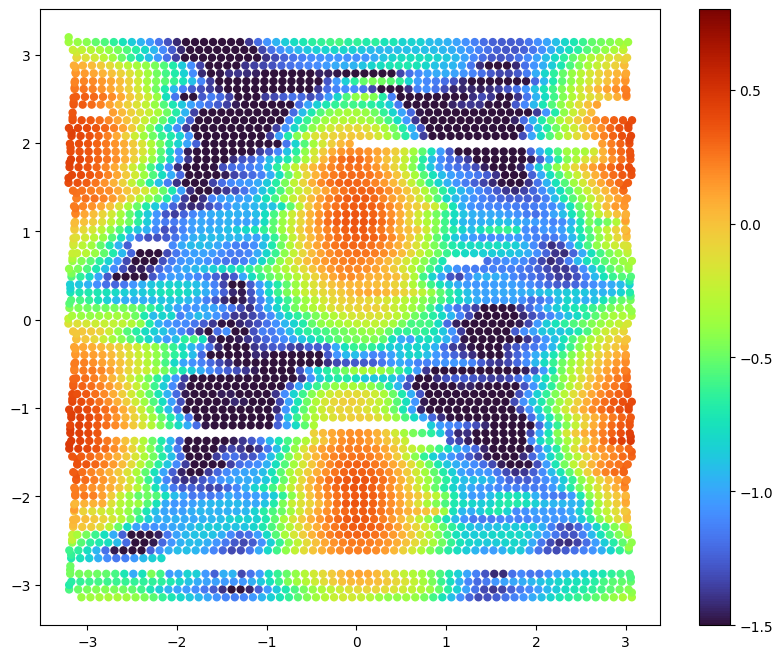

In [30]:
ind = 30
plt.figure(figsize=(10, 8))
plt.scatter(el_inds, az_inds, c=np.log10(y_dat[ind]), s=25, cmap='turbo', vmin=-1.5, vmax=.8)
plt.colorbar()
plt.show()
plt.figure(figsize=(10, 8))
plt.scatter(el_inds, az_inds, c=np.log10(rot[:, ind]*norm[:, ind]), s=25, cmap='turbo', vmin=-1.5, vmax=.8)
plt.colorbar()
plt.show()

In [142]:

lr = 1e-3
nterms = 5
fc = 0.0
fwh = 1e-2
xs = freqs[::16][13:-1]
# xs = freqs[::16][13:]
weights = np.ones_like(xs)
A_mat, _ = hf.dspec.dpss_operator(x=xs, filter_centers=[fc], filter_half_widths=[fwh], nterms=[nterms])
A_mat = jnp.asarray(A_mat)
# y_dat = jnp.asarray(reduced[sl][val][fitter.inds])
y_dat = jnp.asarray(spectra_sims_scan(m_th=beam_maps_th, 
                                      m_ph=beam_maps_ph, 
                                      alphas=best_alphas, 
                                      deltas=best_deltas, 
                                      data=jnp.asarray(reduced[sl][val][fitter.inds])))
print(y_dat.shape)
def loss_fnc(params_raw):
    dpss_th = params_raw[0]
    dpss_ph = params_raw[1]
    rec_th = jax.nn.softplus(A_mat@dpss_th)
    rec_ph = jax.nn.softplus(A_mat@dpss_ph)
    # y_dat = reduced[sl][val][fitter.inds]
    y_mod = spectra_sims_scan(m_th=rec_th, m_ph=rec_ph, alphas=best_alphas, deltas=best_deltas, data=jnp.asarray(reduced[sl][val][fitter.inds]))
    loss = jnp.mean((y_dat - y_mod)**2)
    return loss
# th_init = jnp.ones(shape=(nterms, m_th.shape[0]), dtype=dtype_r) * 1e3
# ph_init = jnp.ones(shape=(nterms, m_ph.shape[0]), dtype=dtype_r) * 1e3

_, th_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=freqs[::16][12:], weights=np.ones_like(freqs[::16][12:]), y=beam_maps_th)
_, ph_init = fit_hera_pack(nterms=nterms, fc=fc, fhw=fwh, x=freqs[::16][12:], weights=np.ones_like(freqs[::16][12:]), y=beam_maps_ph)
print(loss_fnc((th_init, ph_init)))

(50, 4409)
0.06502428530901204


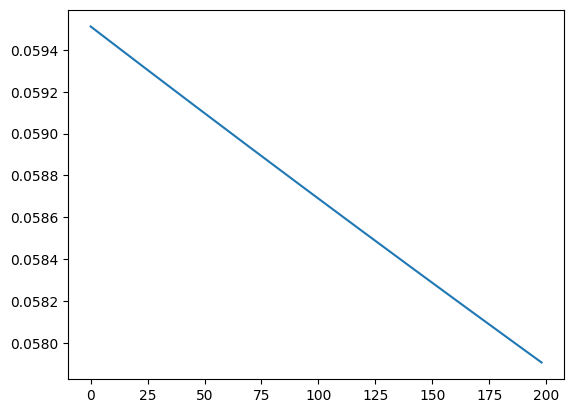

In [83]:
plt.figure()
plt.plot(loss_arr[-200:-1])
plt.show()

In [57]:
# final_th[0].shape
print("final_th shape:", final_th.shape)
print("dtype:", getattr(final_th, "dtype", None))
test_m = jax.device_get(final_th[0])
test_m = np.asarray(test_m)
test_mr = np.real(test_m)
# final_th[0].real

final_th shape: (50, 12288)
dtype: complex128


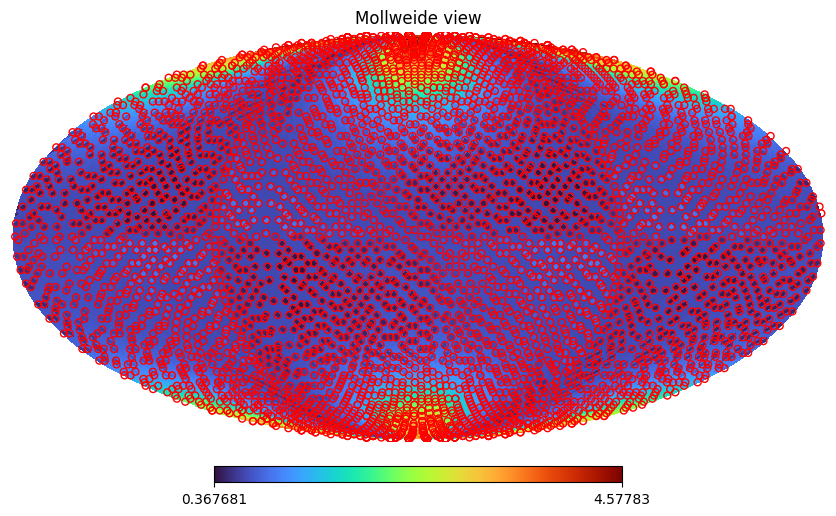

In [366]:

m_test = jnp.full_like(beam_maps_ph[0], healpy.UNSEEN)
# m_dat = jnp.full_like(m_th, healpy.UNSEEN)
m_test = m_test.at[hit_pxs].set(final_th[ind].real[hit_pxs])
unseen_arr = np.where(m_test==healpy.UNSEEN)
test_unseen = jax.nn.softplus(final_th[ind].real)
# test_unseen = test_unseen.at[unseen_arr].set(10)


healpy.mollview(test_unseen, cmap='turbo')
_theta, _phi = healpy.pix2ang(DEFAULT_NSIDE, hit_pxs, nest=False)  # theta=colat [0..pi], phi=lon [0..2pi] in radians

# Overlay hollow red circles
healpy.projscatter(_theta, _phi, lonlat=False,
               s=25, marker='o',
               facecolors='none', edgecolors='r', linewidths=1.0)

plt.show()


In [361]:
unseen_arr[0].shape, hit_pxs.shape

((8457,), (4409,))

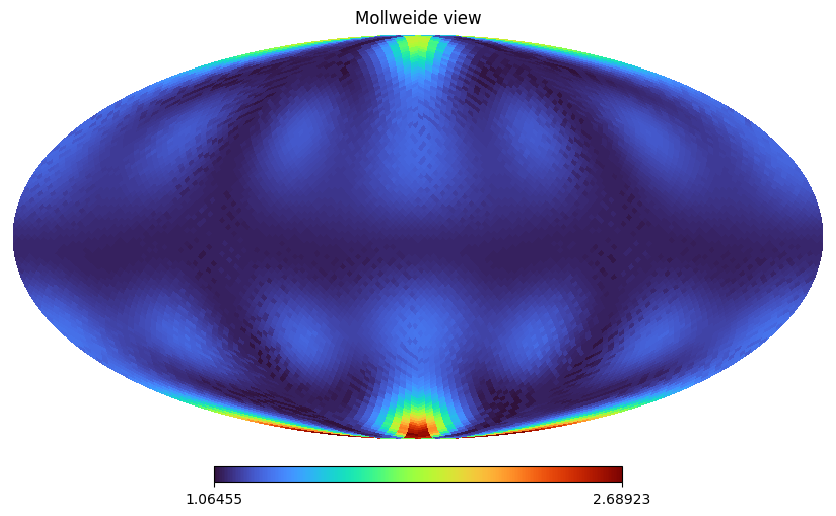

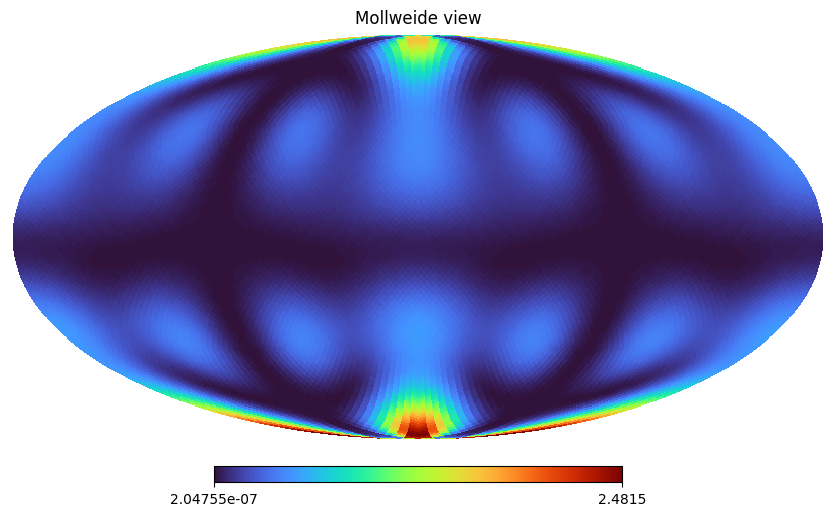

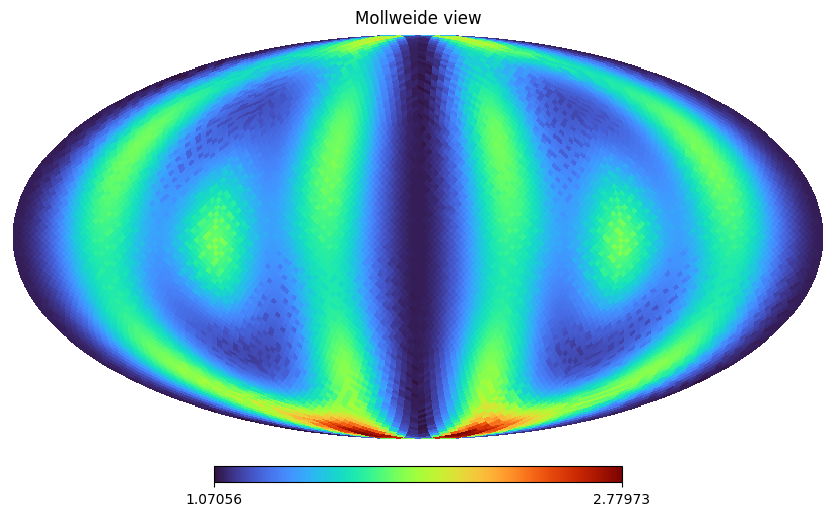

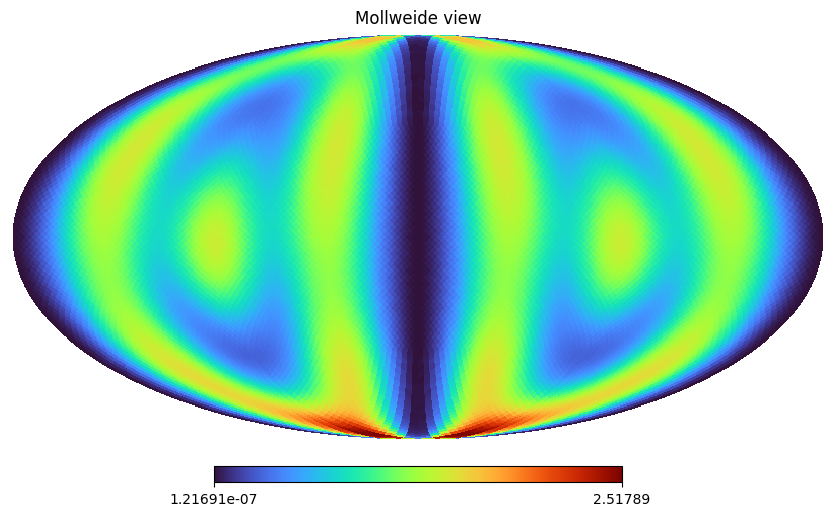

In [84]:
ind = -1
healpy.mollview(jax.nn.softplus(final_th[ind].real), cmap='turbo')
healpy.mollview(beam_maps_th[ind]                  , cmap='turbo')
healpy.mollview(jax.nn.softplus(final_ph[ind].real), cmap='turbo')
healpy.mollview(beam_maps_ph[ind]                  , cmap='turbo')

In [93]:
reduced[:, 13:][sl][val][fitter.inds].shape

(4409, 50)

In [115]:
jnp.mean(y_dat.T[13:,:], axis=(1,0))

Array(34235358.60715242, dtype=float64)

In [75]:
th_fits = fit_hera_pack(nterms=10, fc=fc, fhw=fwh, x=freqs[::16][12:], weights=np.ones_like(freqs[::16][12:]), y=beam_maps_th)

A (52, 10) coeff (10, 12288) model (52, 12288) data (52, 12288)


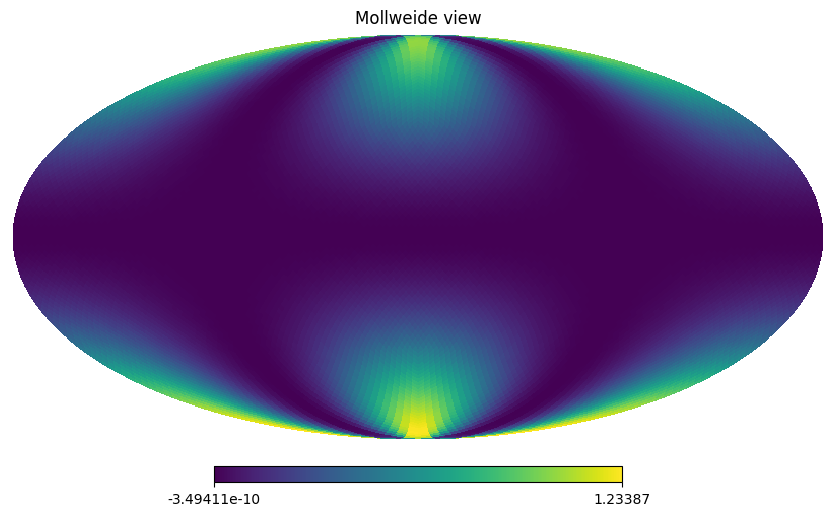

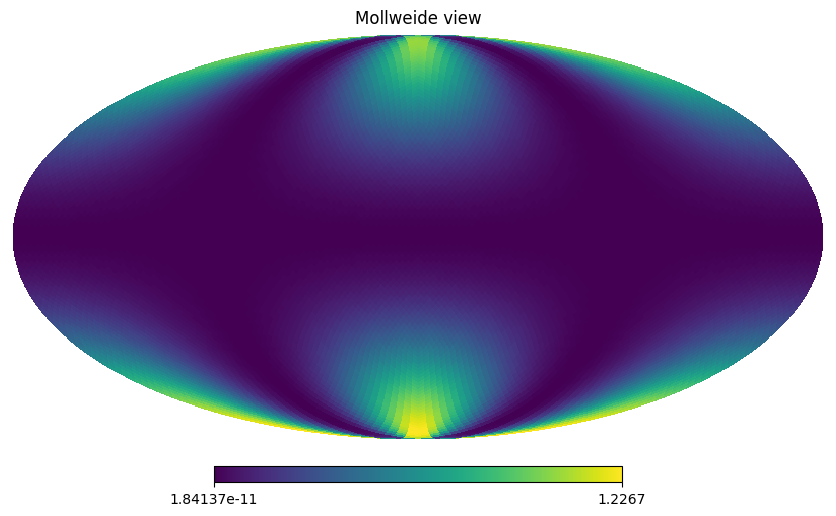

In [90]:
healpy.mollview(  th_fits[0][5])
healpy.mollview(beam_maps_th[5])

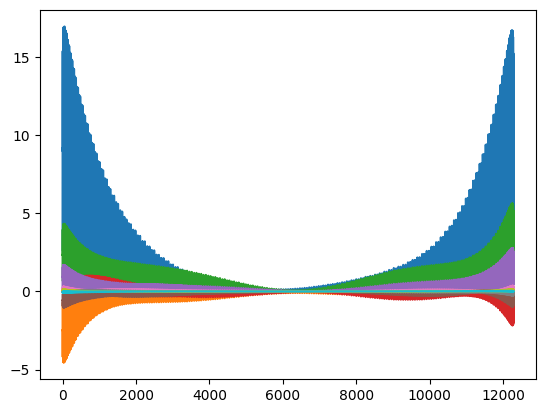

In [87]:
plt.figure()
for i in range(th_fits[1].shape[0]):
    plt.plot(th_fits[1][i])
# plt.plot(th_fits[1][3])
plt.show()